In [1]:
# =============================================================================
# ML for the Quantified Self – Master Notebook
# Gym Movements Dataset: 2 participants × 3 activities × multiple sessions (LOSO evaluation)
# Models: RF, SVM, GBM | LSTM, CNN-LSTM, TCN
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from Python.integrations import load_gym_dataset
from Python.plots import analyze_data_distribution
from Python.windows import create_adaptive_windows
from Python.feature_engineering import engineer_robust_features
from Python.training import train_with_validation

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# ── 1. LOAD GYM MOVEMENTS DATASET ────────────────────────────────────────────
print("Loading Gym Movements Dataset...")
raw_data = load_gym_dataset(Path("./Datasets/cropped"))
print(f"\nTotal samples  : {len(raw_data):,}")
print(f"Participants   : {sorted(raw_data['participant'].unique())}")
print(f"Activities     : {sorted(raw_data['activity_label'].unique())}")
print(f"Sessions total : {raw_data['session'].nunique()}")
print(f"Sessions/person: {raw_data.groupby('participant')['session'].nunique().to_dict()}")
print(f"Columns        : {list(raw_data.columns)}")
raw_data.head(3)


Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 175,573
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
  Sessions      : 74
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'magnet_x', 'magnet_y', 'magnet_z', 'acc_vert', 'acc_horiz', 'gyro_vert', 'gyro_horiz', 'activity_label', 'participant', 'session', 'data_source']

Total samples  : 175,573
Participants   : ['imaan', 'richard']
Activities     : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
Sessions total : 74
Sessions/person: {'imaan': 48, 'richard': 26}
Columns        : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'mag

,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,grav_x,grav_y,grav_z,...,magnet_y,magnet_z,acc_vert,acc_horiz,gyro_vert,gyro_horiz,activity_label,participant,session,data_source
0,0.000000,0.173412,-1.01202,0.230539,-0.707987,-0.479600,1.101513,-0.662412,-3.447979,9.149461,...,28.106251,-35.343750,0.559578,0.891222,1.244987,0.628171,elliptical,imaan,0,original
1,0.019519,0.240469,-1.24172,0.357223,-0.643775,-0.588225,1.202713,-0.647469,-3.455279,9.147778,...,27.018751,-38.737503,0.755366,1.075511,1.372597,0.568286,elliptical,imaan,0,original
2,0.039040,0.269452,-1.34355,0.356299,-0.576950,-0.688187,1.316975,-0.638452,-3.462449,9.145700,...,27.693750,-37.425003,0.789647,1.175218,1.509778,0.511338,elliptical,imaan,0,original


In [2]:
# ── 2. MISSING VALUE HANDLING (Point 3) ──────────────────────────────────────
SENSOR_COLS = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z",
               "grav_x", "grav_y", "grav_z",
               "orient_qz", "orient_qy", "orient_qx", "orient_qw",
               "orient_roll", "orient_pitch", "orient_yaw",
               "magnet_x", "magnet_y", "magnet_z",
               "acc_vert", "acc_horiz", "gyro_vert", "gyro_horiz"]

missing = raw_data[SENSOR_COLS].isnull().sum()
print("=== Missing Value Analysis ===")
print(f"Per-channel missing values:\n{missing.to_string()}")
total_missing = int(missing.sum())
print(f"\nTotal missing sensor readings: {total_missing}")

if total_missing > 0:
    print("\nApplying linear interpolation per (participant, session)...")
    raw_data[SENSOR_COLS] = (
        raw_data.groupby(["participant", "session"])[SENSOR_COLS]
        .transform(
            lambda g: g.interpolate(method="linear")
                       .ffill()
                       .bfill()
        )
    )
    remaining = int(raw_data[SENSOR_COLS].isnull().sum().sum())
    print(f"Remaining missing after interpolation: {remaining}")
else:
    print("\nNo missing values detected — dataset is complete.")

=== Missing Value Analysis ===
Per-channel missing values:
acc_x           0
acc_y           0
acc_z           0
gyro_x          3
gyro_y          3
gyro_z          3
grav_x          6
grav_y          6
grav_z          6
orient_qz       3
orient_qy       3
orient_qx       3
orient_qw       3
orient_roll     3
orient_pitch    3
orient_yaw      3
magnet_x        4
magnet_y        4
magnet_z        4
acc_vert        6
acc_horiz       6
gyro_vert       6
gyro_horiz      6

Total missing sensor readings: 84

Applying linear interpolation per (participant, session)...
Remaining missing after interpolation: 0


=== Exploratory Data Analysis ===


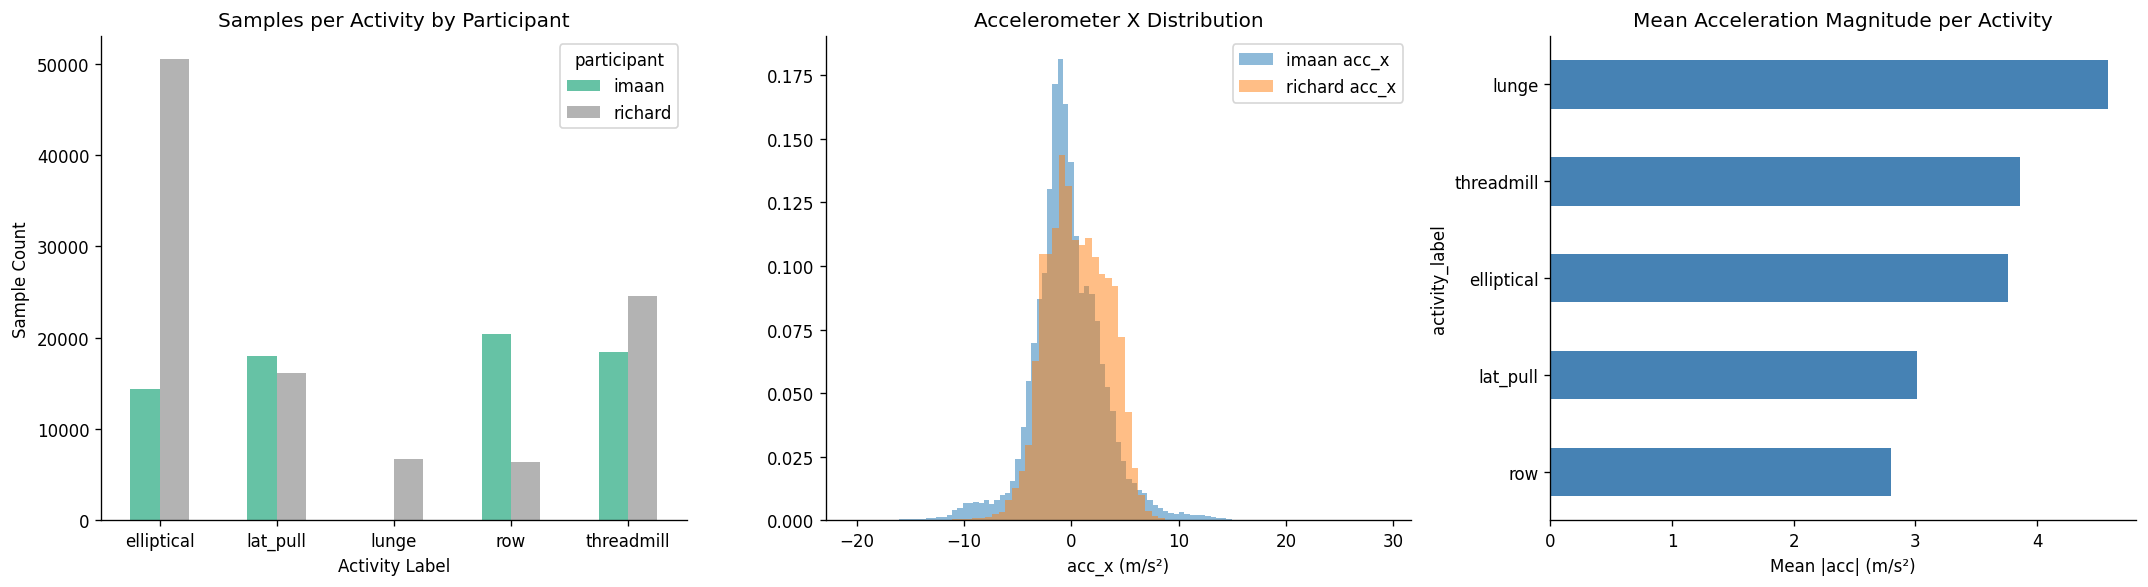


Class balance (samples per activity):
activity_label
elliptical    64860
lat_pull      34220
lunge          6758
row           26742
threadmill    42993

Sensor statistics:
            acc_x       acc_y       acc_z      gyro_x      gyro_y      gyro_z      grav_x      grav_y      grav_z   orient_qz   orient_qy   orient_qx   orient_qw  orient_roll  orient_pitch  orient_yaw    magnet_x    magnet_y    magnet_z    acc_vert   acc_horiz   gyro_vert  gyro_horiz
count  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000   175573.000    175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000  175573.000
mean        0.176      -0.235       0.005       0.015      -0.067       0.088      -0.519      -4.146       4.478       0.016       0.033      -0.239       0.670        0.090         0.473      -0.144       4.688      34.212     -22.117      -0.038       2

In [3]:

# ── 3. EXPLORATORY DATA ANALYSIS (Point 2) ───────────────────────────────────
print("=== Exploratory Data Analysis ===")

# Activity label distribution
if "activity_label" in raw_data.columns:
    act_col = "activity_label"
elif "activity" in raw_data.columns:
    act_col = "activity"
else:
    raise RuntimeError("No activity label column found in raw_data.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Samples per activity
act_counts = raw_data.groupby([act_col, "participant"]).size().unstack(fill_value=0)
act_counts.plot(kind="bar", ax=axes[0], colormap="Set2")
axes[0].set_title("Samples per Activity by Participant")
axes[0].set_xlabel("Activity Label")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=0)

# (b) Accelerometer distributions
for p, ls in zip(sorted(raw_data["participant"].unique()), ["-", "--"]):
    pdata = raw_data[raw_data["participant"] == p]
    axes[1].hist(pdata["acc_x"], bins=80, alpha=0.5, density=True, label=f"{p} acc_x", linestyle=ls)
axes[1].set_title("Accelerometer X Distribution")
axes[1].set_xlabel("acc_x (m/s²)")
axes[1].legend()

# (c) Gyroscope by activity (mean acc magnitude)
raw_data["acc_mag"] = np.sqrt(
    raw_data["acc_x"]**2 + raw_data["acc_y"]**2 + raw_data["acc_z"]**2
)
act_mag = raw_data.groupby(act_col)["acc_mag"].mean().sort_values()
act_mag.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Mean Acceleration Magnitude per Activity")
axes[2].set_xlabel("Mean |acc| (m/s²)")

plt.tight_layout()
plt.savefig("./Plots/field_data_eda.png", dpi=150, bbox_inches="tight")
plt.show()

# Class balance report
print("\nClass balance (samples per activity):")
print(raw_data[act_col].value_counts().sort_index().to_string())
print(f"\nSensor statistics:\n{raw_data[SENSOR_COLS].describe().round(3).to_string()}")


In [4]:

# ── 4. WINDOWING & FEATURE ENGINEERING (Point 4) ─────────────────────────────
print("=== Windowing ===")
windowed_data = create_adaptive_windows(
    raw_data,
    min_window_size=64,
    preferred_window_size=128,   # 2.56 s @ 50 Hz
    overlap_ratio=0.5,
)

print("\n=== Feature Engineering ===")
features, labels, feature_names, metadata = engineer_robust_features(
    windowed_data, sampling_rate=50
)

print(f"\nFeature matrix shape: {features.shape}")
print(f"Label distribution  : {dict(zip(*np.unique(labels, return_counts=True)))}")

participants = np.array([m["participant"] for m in metadata])
print(f"Windows per participant: "
      f"{dict(zip(*np.unique(participants, return_counts=True)))}")


=== Windowing ===

Window creation summary:
  Full-size windows: 2633
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 2633

=== Feature Engineering ===
  Processing window 0/2633...
  Processing window 100/2633...
  Processing window 200/2633...
  Processing window 300/2633...
  Processing window 400/2633...
  Processing window 500/2633...
  Processing window 600/2633...
  Processing window 700/2633...
  Processing window 800/2633...
  Processing window 900/2633...
  Processing window 1000/2633...
  Processing window 1100/2633...
  Processing window 1200/2633...
  Processing window 1300/2633...
  Processing window 1400/2633...
  Processing window 1500/2633...
  Processing window 1600/2633...
  Processing window 1700/2633...
  Processing window 1800/2633...
  Processing window 1900/2633...
  Processing window 2000/2633...
  Processing window 2100/2633...
  Processing window 2200/2633...
  Processing window 2300/2633...
  Processing window 2400/2633...
  Processing window 2

['acc_x_mean', 'acc_x_std', 'acc_x_max', 'acc_x_min', 'acc_x_median', 'acc_x_skew', 'acc_x_kurtosis', 'acc_x_q25', 'acc_x_q75', 'acc_x_q90', 'acc_x_q10', 'acc_x_mean_abs', 'acc_x_rms', 'acc_x_range', 'acc_x_zcr', 'acc_x_spectral_centroid', 'acc_x_spectral_spread', 'acc_x_low_band_power', 'acc_x_mid_band_power', 'acc_x_high_band_power', 'acc_x_spectral_entropy', 'acc_y_mean', 'acc_y_std', 'acc_y_max', 'acc_y_min', 'acc_y_median', 'acc_y_skew', 'acc_y_kurtosis', 'acc_y_q25', 'acc_y_q75', 'acc_y_q90', 'acc_y_q10', 'acc_y_mean_abs', 'acc_y_rms', 'acc_y_range', 'acc_y_zcr', 'acc_y_spectral_centroid', 'acc_y_spectral_spread', 'acc_y_low_band_power', 'acc_y_mid_band_power', 'acc_y_high_band_power', 'acc_y_spectral_entropy', 'acc_z_mean', 'acc_z_std', 'acc_z_max', 'acc_z_min', 'acc_z_median', 'acc_z_skew', 'acc_z_kurtosis', 'acc_z_q25', 'acc_z_q75', 'acc_z_q90', 'acc_z_q10', 'acc_z_mean_abs', 'acc_z_rms', 'acc_z_range', 'acc_z_zcr', 'acc_z_spectral_centroid', 'acc_z_spectral_spread', 'acc_z_lo

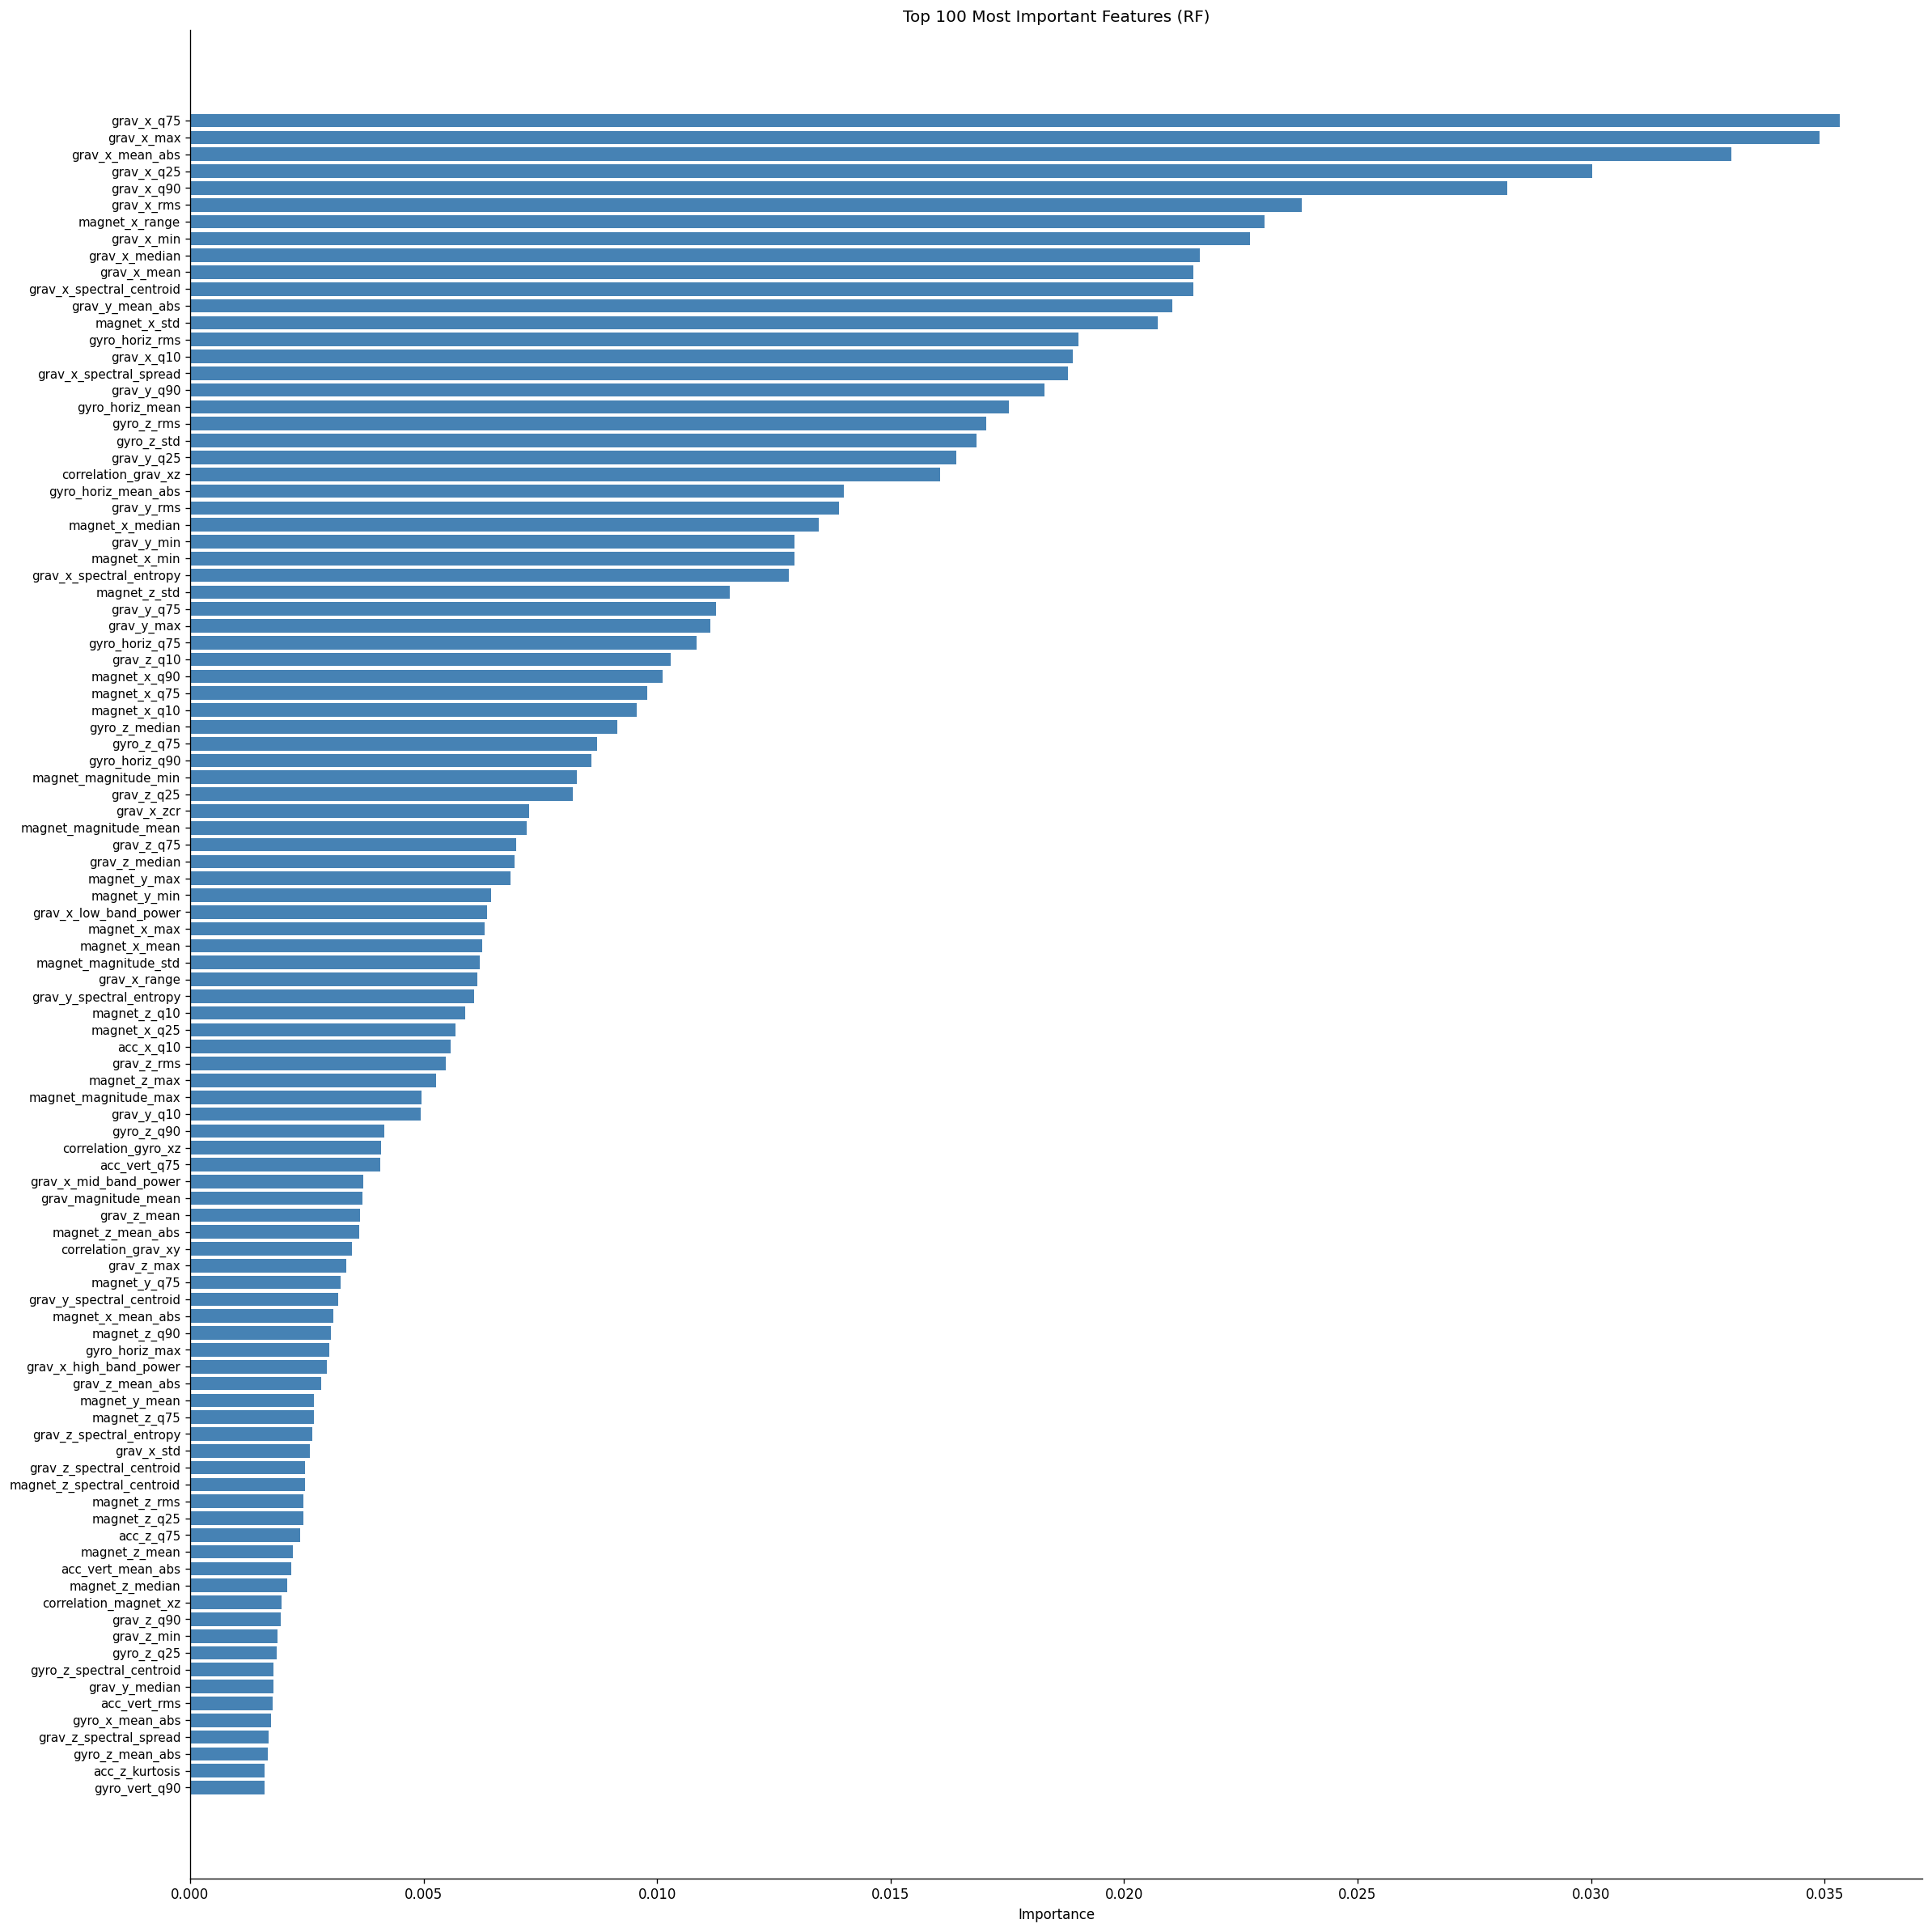

Top 5 features:
  1. grav_x_q75                               0.0353
  2. grav_x_max                               0.0349
  3. grav_x_mean_abs                          0.0330
  4. grav_x_q25                               0.0300
  5. grav_x_q90                               0.0282


In [5]:
# ── 5. FEATURE IMPORTANCE (Point 4) ──────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

print(feature_names)
# Quick RF for feature importance (stratified, not the final eval split)
scaler_tmp = StandardScaler()
feat_scaled = scaler_tmp.fit_transform(features)

rf_tmp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_tmp.fit(feat_scaled, labels)

importances = rf_tmp.feature_importances_
top_k = 100
top_idx = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(20, 20))
ax.barh(
    range(top_k),
    importances[top_idx][::-1],
    color="steelblue",
)
ax.set_yticks(range(top_k))
ax.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_k} Most Important Features (RF)")
plt.tight_layout()
plt.savefig("./Plots/field_data_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top 5 features:")
for rank, idx in enumerate(top_idx[:5], 1):
    print(f"  {rank}. {feature_names[idx]:40s} {importances[idx]:.4f}")



  RF – Mixed-LOSO

=== Training [RF] with [mixed_loso] validation ===

  Mixed-LOSO fold 1/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2026, test=607)

Test Accuracy [RF fold=1]: 0.9687
              precision    recall  f1-score   support

  elliptical       0.94      0.99      0.96       250
    lat_pull       0.98      0.72      0.83        61
       lunge       1.00      1.00      1.00        24
         row       0.99      1.00      0.99        89
  threadmill       1.00      1.00      1.00       183

    accuracy                           0.97       607
   macro avg       0.98      0.94      0.96       607
weighted avg       0.97      0.97      0.97       607



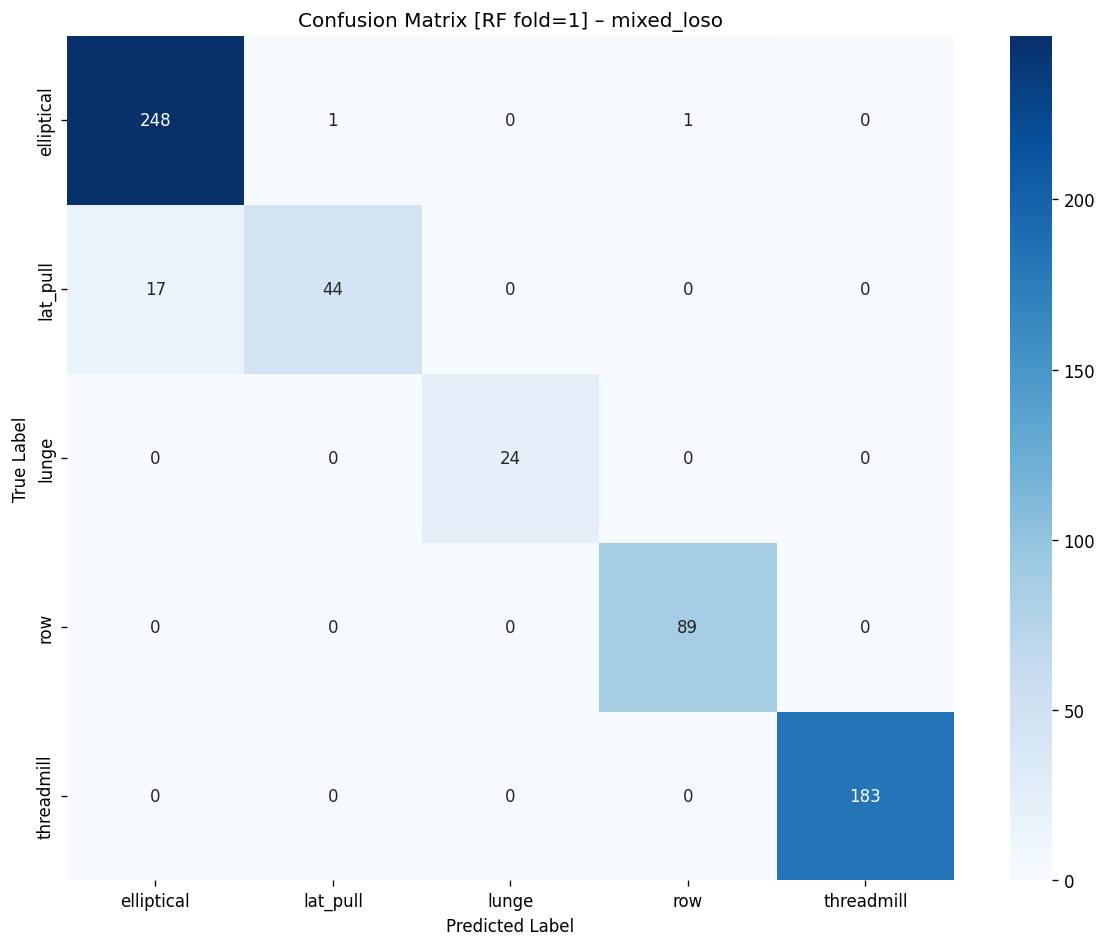


  Mixed-LOSO fold 2/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2131, test=502)

Test Accuracy [RF fold=2]: 0.9582
              precision    recall  f1-score   support

  elliptical       1.00      1.00      1.00       258
    lat_pull       0.80      0.97      0.88        79
       lunge       0.92      1.00      0.96        24
         row       1.00      1.00      1.00        81
  threadmill       1.00      0.68      0.81        60

    accuracy                           0.96       502
   macro avg       0.95      0.93      0.93       502
weighted avg       0.97      0.96      0.96       502



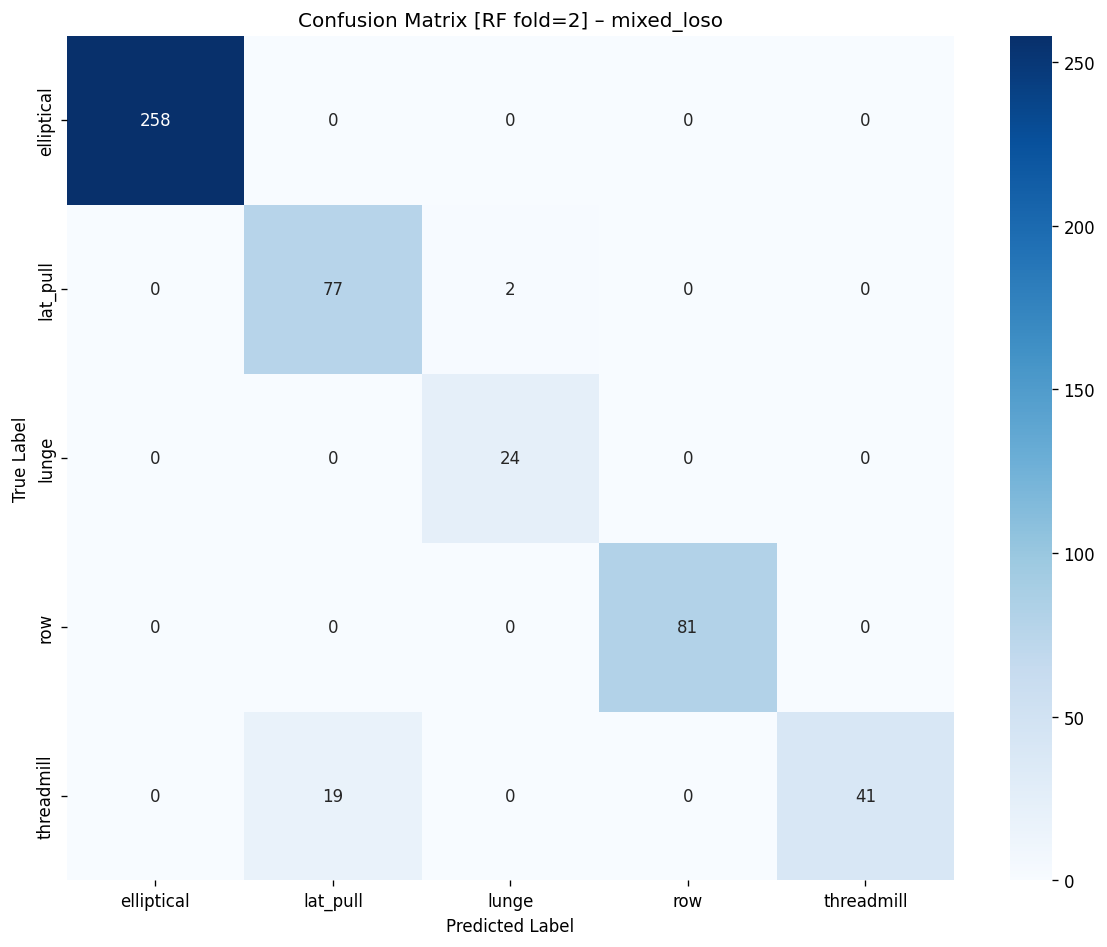


  Mixed-LOSO fold 3/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2175, test=458)

Test Accuracy [RF fold=3]: 0.9498
              precision    recall  f1-score   support

  elliptical       1.00      0.98      0.99       152
    lat_pull       1.00      0.86      0.92       139
       lunge       0.96      1.00      0.98        25
         row       0.96      1.00      0.98        76
  threadmill       0.78      1.00      0.87        66

    accuracy                           0.95       458
   macro avg       0.94      0.97      0.95       458
weighted avg       0.96      0.95      0.95       458



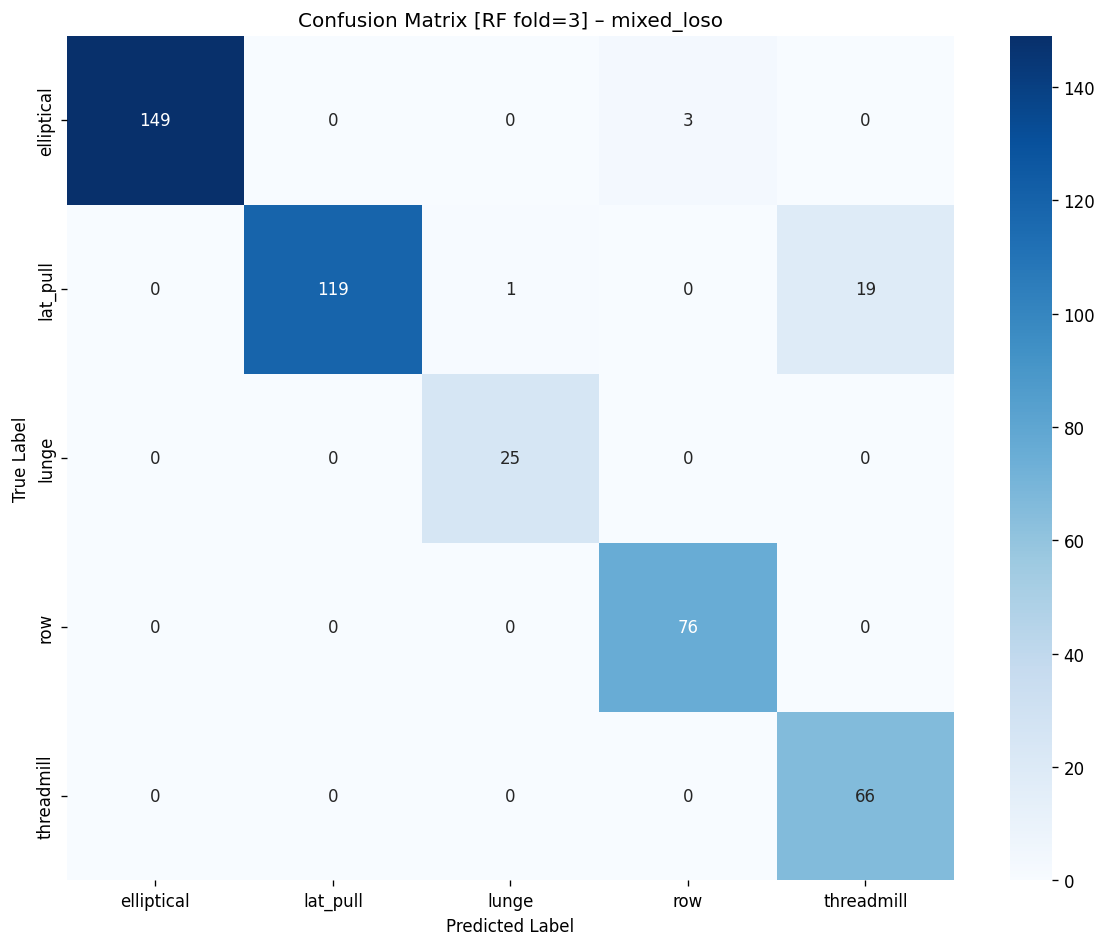


  Mixed-LOSO fold 4/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2079, test=554)

Test Accuracy [RF fold=4]: 0.9675
              precision    recall  f1-score   support

  elliptical       0.99      0.91      0.95       186
    lat_pull       0.89      1.00      0.94       131
       lunge       1.00      0.96      0.98        27
         row       1.00      1.00      1.00        51
  threadmill       1.00      1.00      1.00       159

    accuracy                           0.97       554
   macro avg       0.98      0.97      0.97       554
weighted avg       0.97      0.97      0.97       554



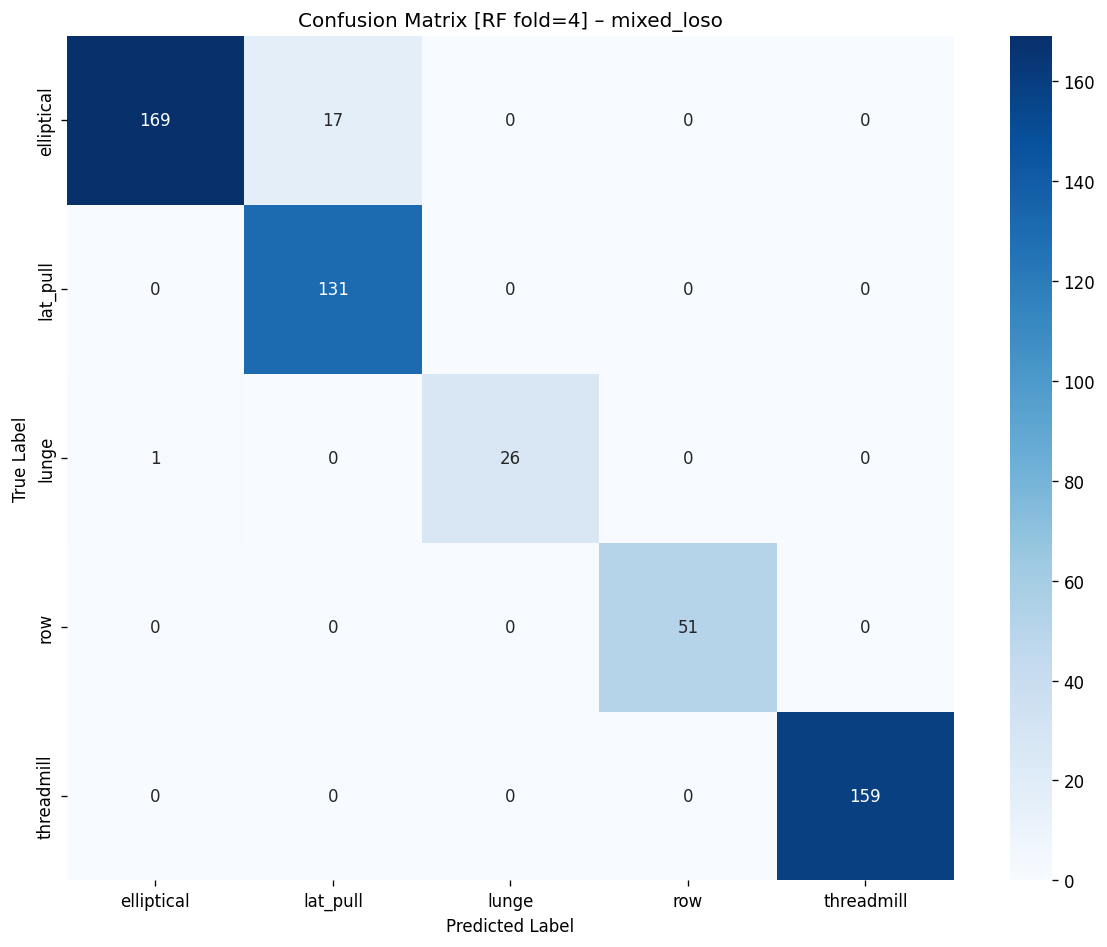


  Mixed-LOSO fold 5/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2121, test=512)

Test Accuracy [RF fold=5]: 0.9980
              precision    recall  f1-score   support

  elliptical       1.00      1.00      1.00       138
    lat_pull       1.00      1.00      1.00        96
       lunge       0.00      0.00      0.00         0
         row       1.00      1.00      1.00        96
  threadmill       1.00      0.99      1.00       182

    accuracy                           1.00       512
   macro avg       0.80      0.80      0.80       512
weighted avg       1.00      1.00      1.00       512



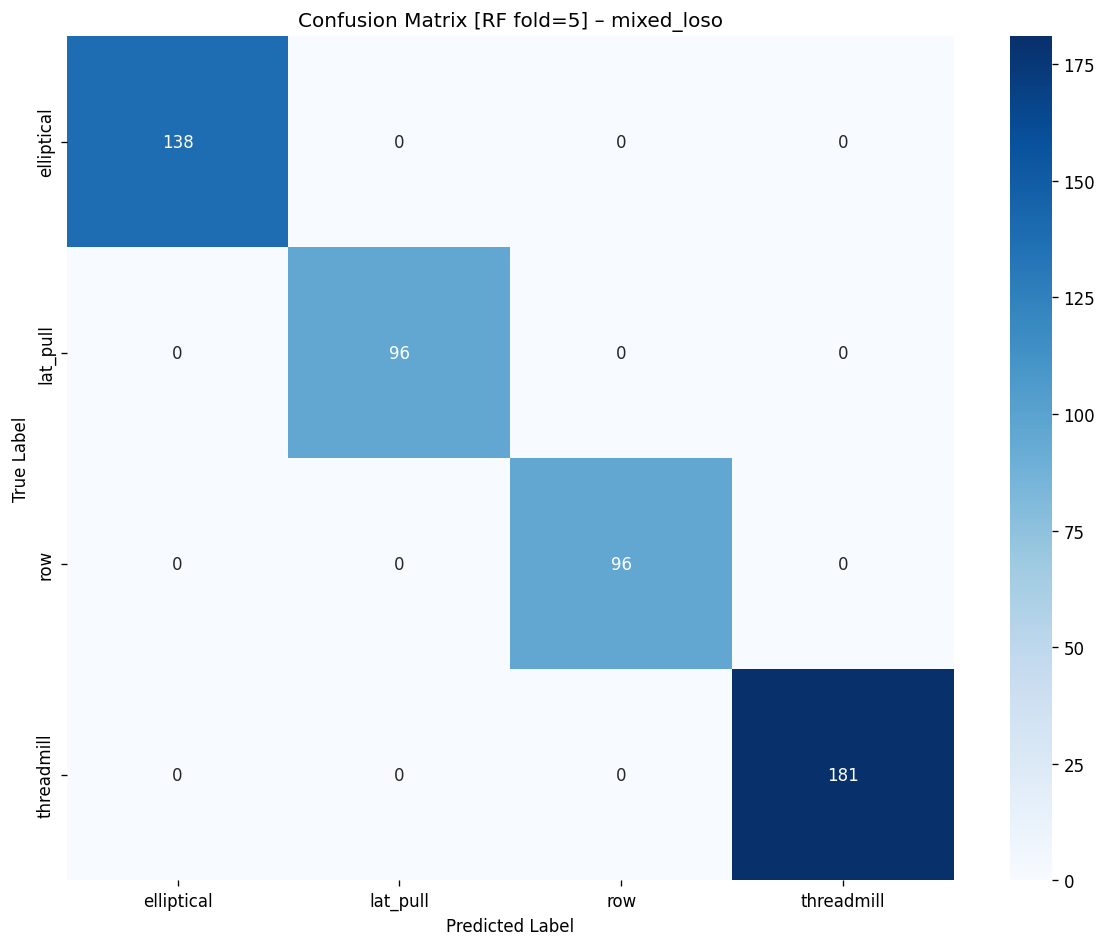


  Mixed-LOSO Mean Accuracy (RF): 0.9684
  Per-fold: {'fold_1': 0.9686985172981878, 'fold_2': 0.9581673306772909, 'fold_3': 0.9497816593886463, 'fold_4': 0.9675090252707581, 'fold_5': 0.998046875}

  SVM – Mixed-LOSO

=== Training [SVM] with [mixed_loso] validation ===

  Mixed-LOSO fold 1/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2026, test=607)

Test Accuracy [SVM fold=1]: 0.9654
              precision    recall  f1-score   support

  elliptical       0.93      0.99      0.96       250
    lat_pull       0.96      0.72      0.82        61
       lunge       1.00      1.00      1.00        24
         row       1.00      1.00      1.00        89
  threadmill       1.00      0.99      0.99       183

    accuracy                           0.97       607
   macro avg       0.98      0.94      0.96       607
weighted avg       0.97      0.97      0.96       607



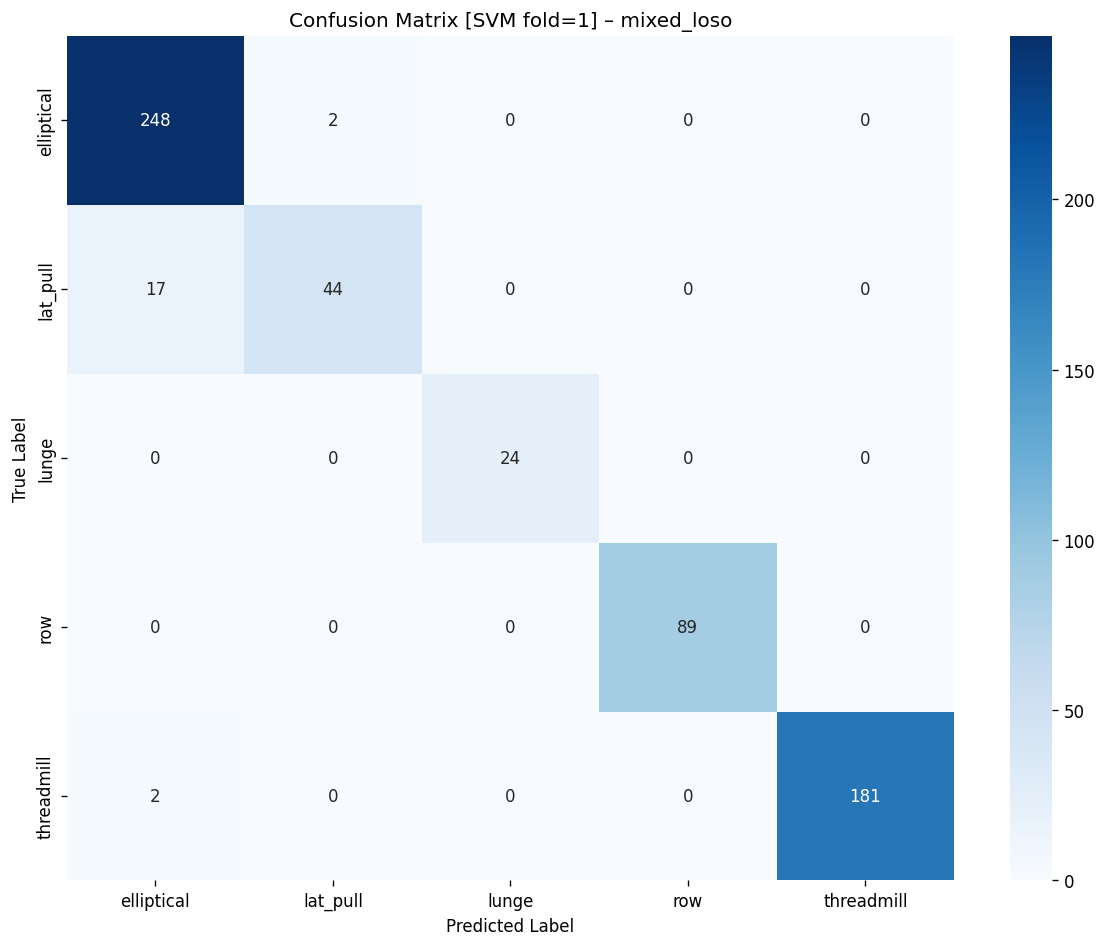


  Mixed-LOSO fold 2/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2131, test=502)

Test Accuracy [SVM fold=2]: 0.9442
              precision    recall  f1-score   support

  elliptical       0.99      0.97      0.98       258
    lat_pull       0.75      0.97      0.85        79
       lunge       1.00      1.00      1.00        24
         row       1.00      1.00      1.00        81
  threadmill       1.00      0.68      0.81        60

    accuracy                           0.94       502
   macro avg       0.95      0.93      0.93       502
weighted avg       0.96      0.94      0.94       502



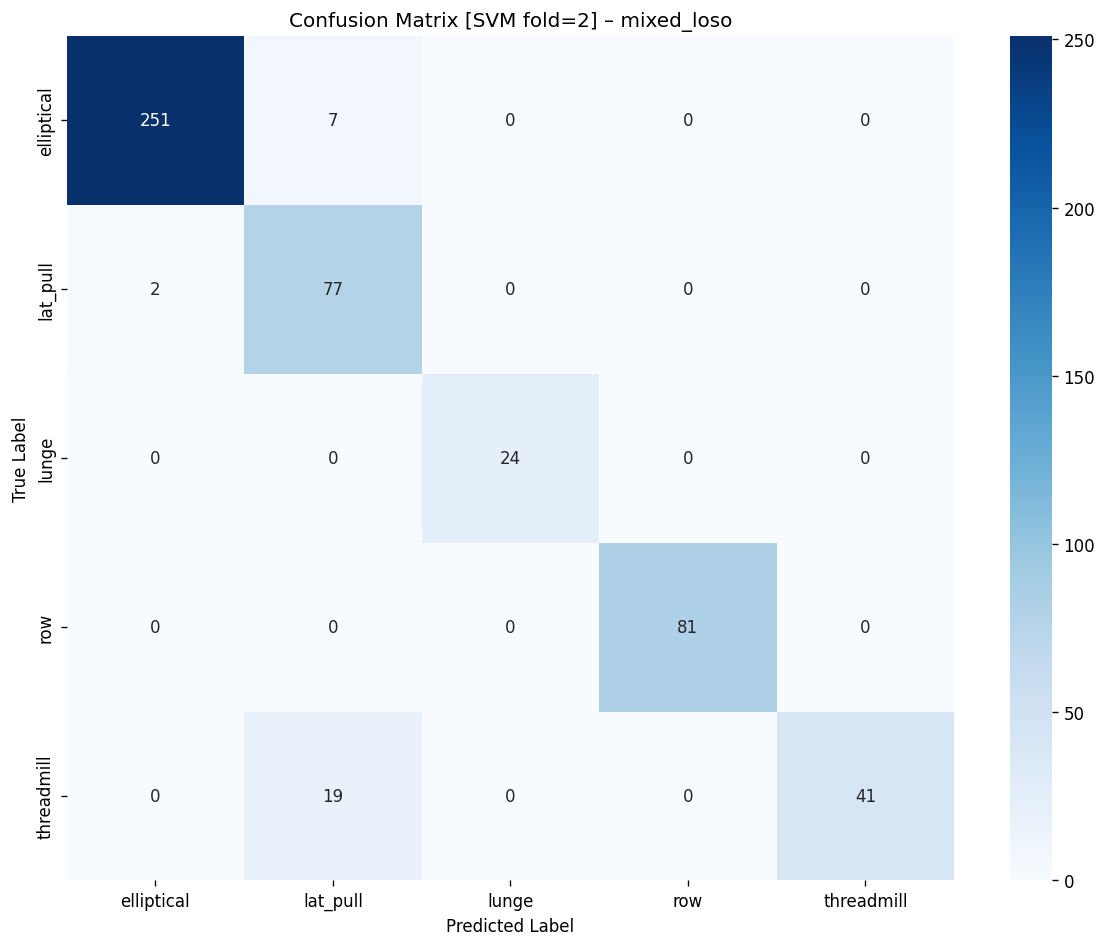


  Mixed-LOSO fold 3/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2175, test=458)

Test Accuracy [SVM fold=3]: 0.9520
              precision    recall  f1-score   support

  elliptical       1.00      0.99      0.99       152
    lat_pull       1.00      0.86      0.92       139
       lunge       1.00      1.00      1.00        25
         row       0.97      1.00      0.99        76
  threadmill       0.77      1.00      0.87        66

    accuracy                           0.95       458
   macro avg       0.95      0.97      0.95       458
weighted avg       0.96      0.95      0.95       458



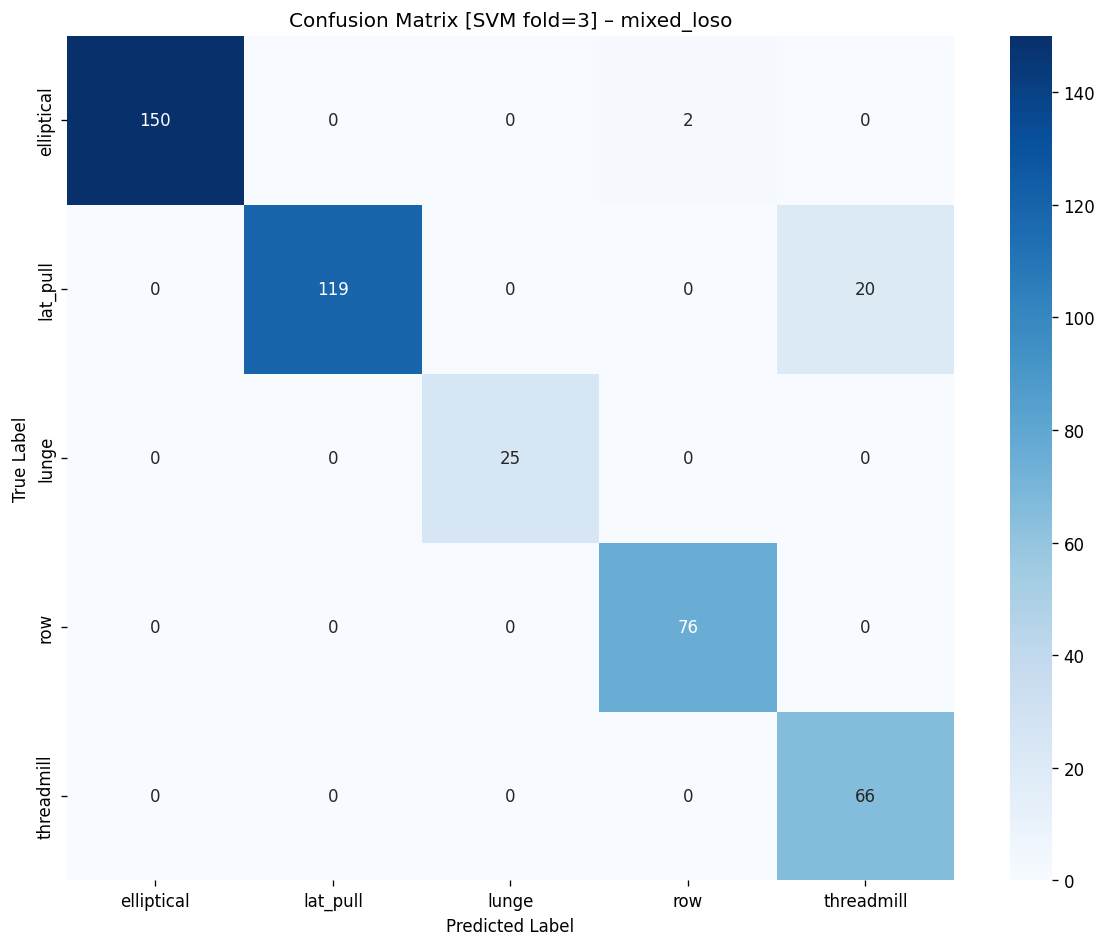


  Mixed-LOSO fold 4/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2079, test=554)

Test Accuracy [SVM fold=4]: 0.9693
              precision    recall  f1-score   support

  elliptical       1.00      0.91      0.95       186
    lat_pull       0.89      1.00      0.94       131
       lunge       1.00      1.00      1.00        27
         row       1.00      1.00      1.00        51
  threadmill       1.00      1.00      1.00       159

    accuracy                           0.97       554
   macro avg       0.98      0.98      0.98       554
weighted avg       0.97      0.97      0.97       554



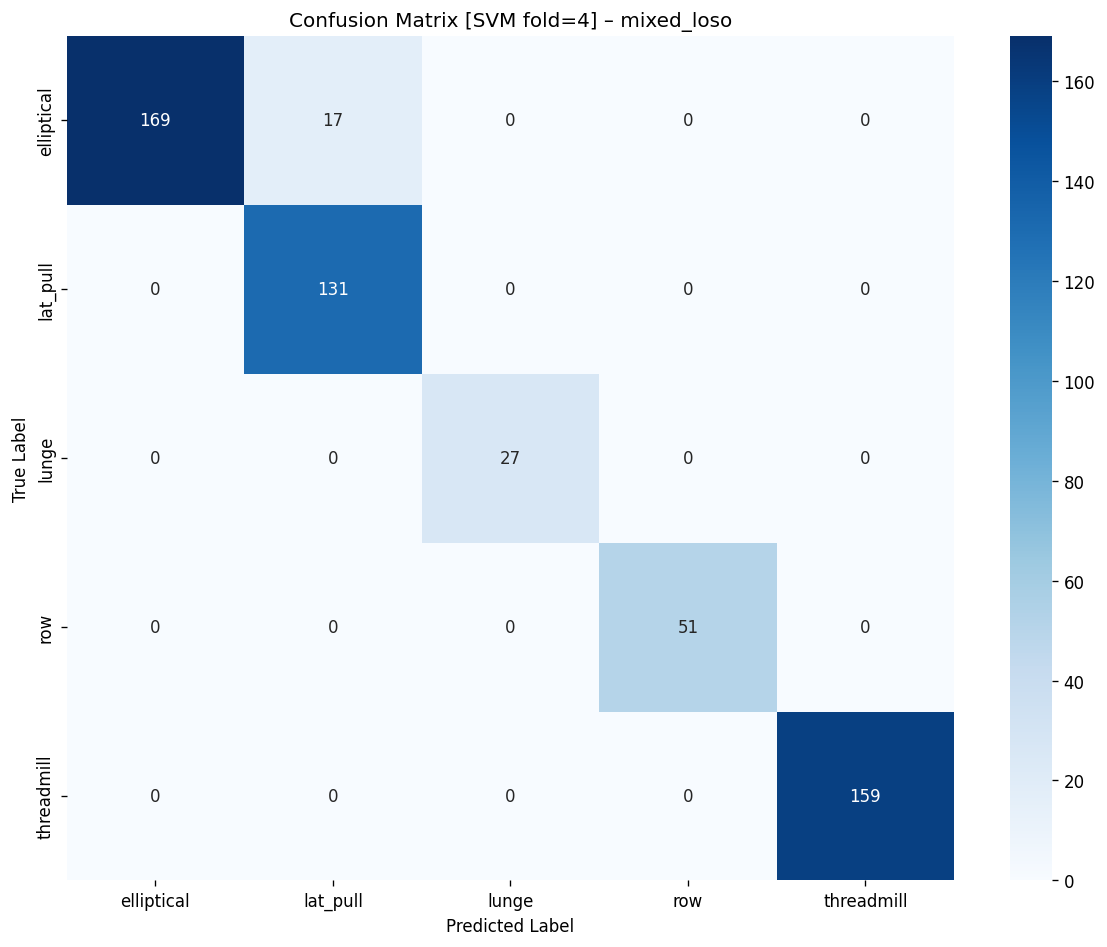


  Mixed-LOSO fold 5/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2121, test=512)

Test Accuracy [SVM fold=5]: 0.9805
              precision    recall  f1-score   support

  elliptical       1.00      0.95      0.97       138
    lat_pull       0.91      1.00      0.96        96
       lunge       0.00      0.00      0.00         0
         row       1.00      1.00      1.00        96
  threadmill       1.00      0.98      0.99       182

    accuracy                           0.98       512
   macro avg       0.78      0.79      0.78       512
weighted avg       0.98      0.98      0.98       512



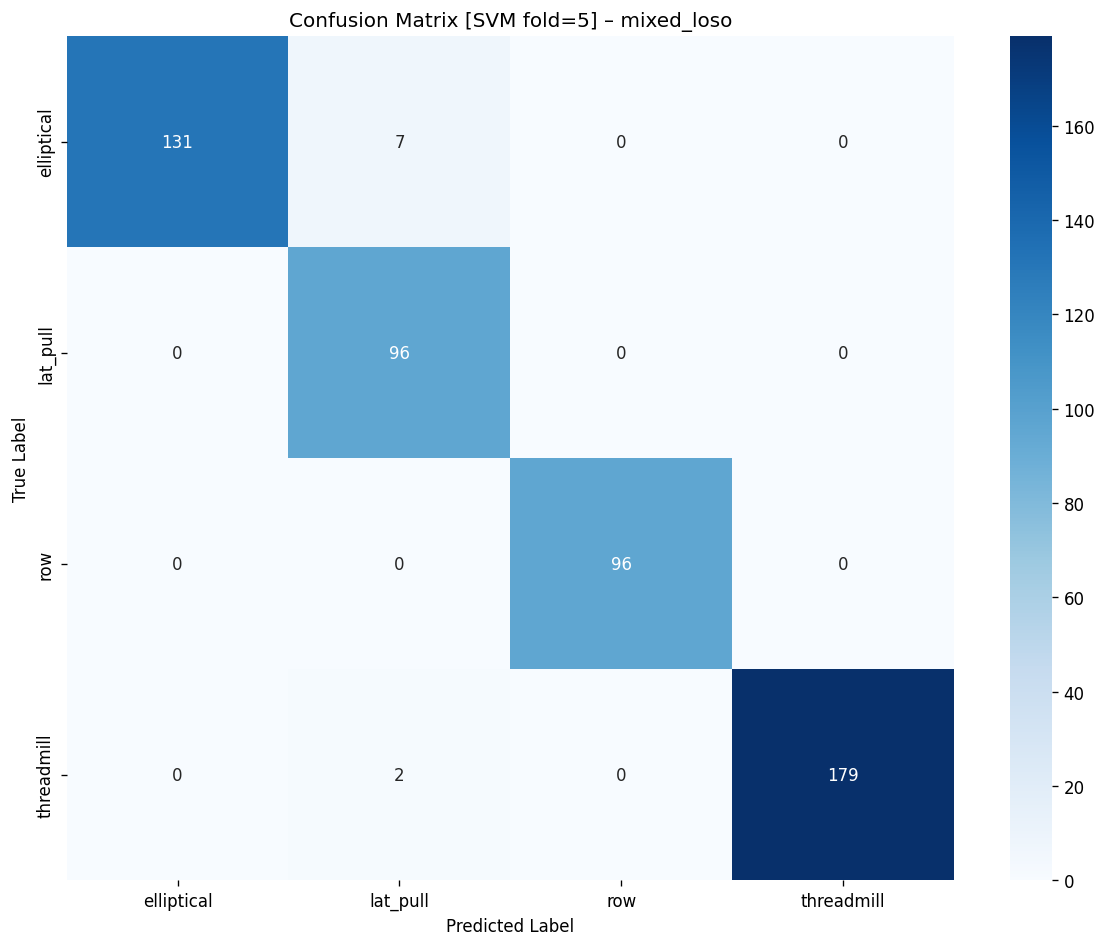


  Mixed-LOSO Mean Accuracy (SVM): 0.9623
  Per-fold: {'fold_1': 0.9654036243822076, 'fold_2': 0.9442231075697212, 'fold_3': 0.9519650655021834, 'fold_4': 0.9693140794223827, 'fold_5': 0.98046875}

  GBM – Mixed-LOSO

=== Training [GBM] with [mixed_loso] validation ===

  Mixed-LOSO fold 1/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2026, test=607)

Test Accuracy [GBM fold=1]: 0.9687
              precision    recall  f1-score   support

  elliptical       0.94      0.99      0.96       250
    lat_pull       1.00      0.72      0.84        61
       lunge       0.96      1.00      0.98        24
         row       0.99      1.00      0.99        89
  threadmill       1.00      1.00      1.00       183

    accuracy                           0.97       607
   macro avg       0.98      0.94      0.96       607
weighted avg       0.97      0.97      0.97       607



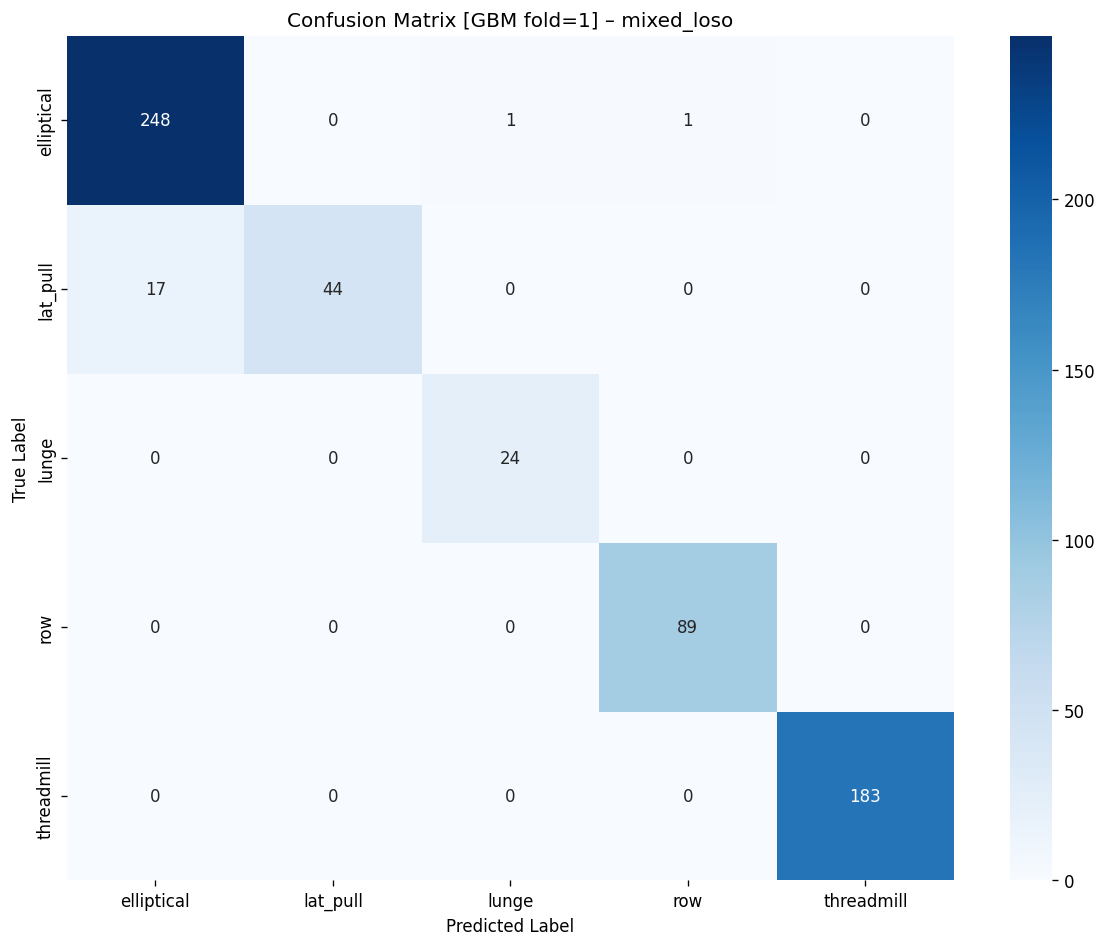


  Mixed-LOSO fold 2/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2131, test=502)

Test Accuracy [GBM fold=2]: 0.9602
              precision    recall  f1-score   support

  elliptical       1.00      1.00      1.00       258
    lat_pull       0.80      0.99      0.89        79
       lunge       1.00      1.00      1.00        24
         row       1.00      1.00      1.00        81
  threadmill       0.98      0.68      0.80        60

    accuracy                           0.96       502
   macro avg       0.96      0.93      0.94       502
weighted avg       0.97      0.96      0.96       502



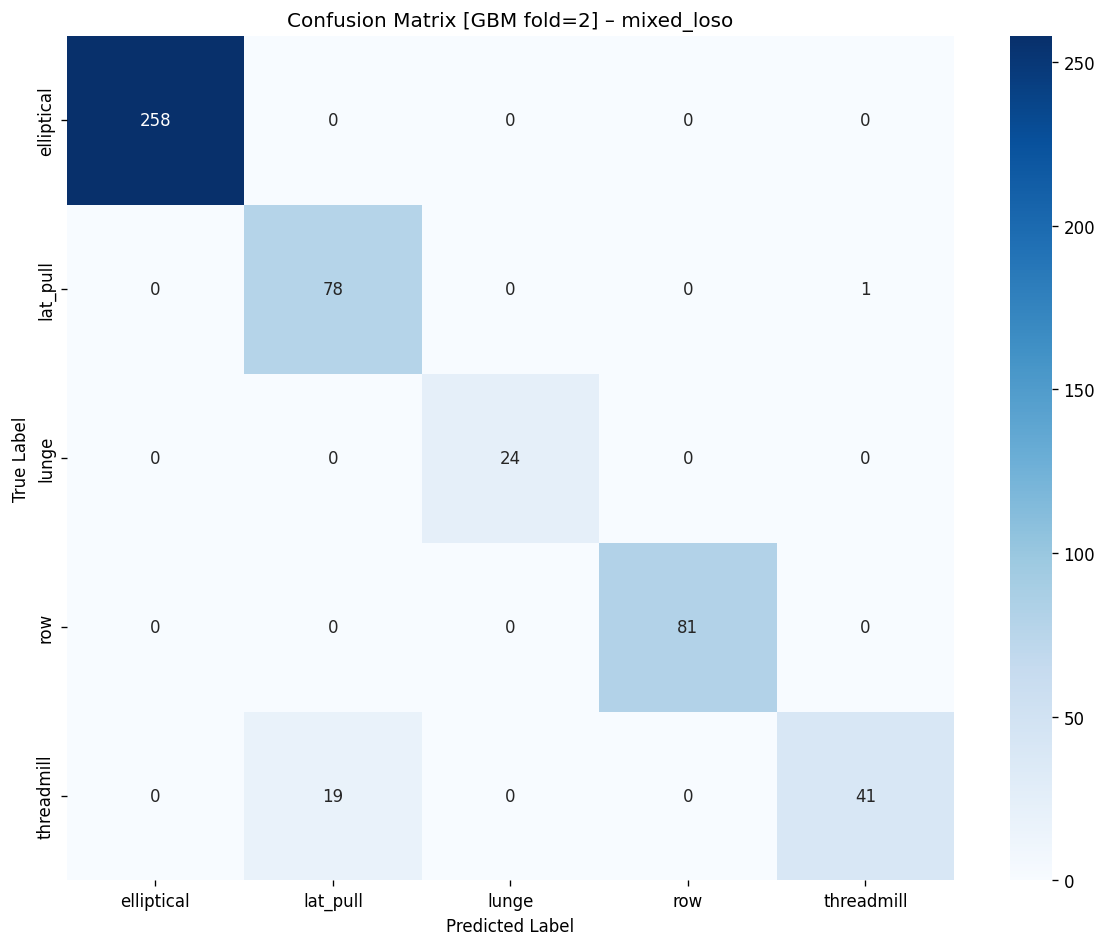


  Mixed-LOSO fold 3/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2175, test=458)

Test Accuracy [GBM fold=3]: 0.9389
              precision    recall  f1-score   support

  elliptical       0.99      0.97      0.98       152
    lat_pull       1.00      0.85      0.92       139
       lunge       0.93      1.00      0.96        25
         row       0.94      0.97      0.95        76
  threadmill       0.78      1.00      0.87        66

    accuracy                           0.94       458
   macro avg       0.93      0.96      0.94       458
weighted avg       0.95      0.94      0.94       458



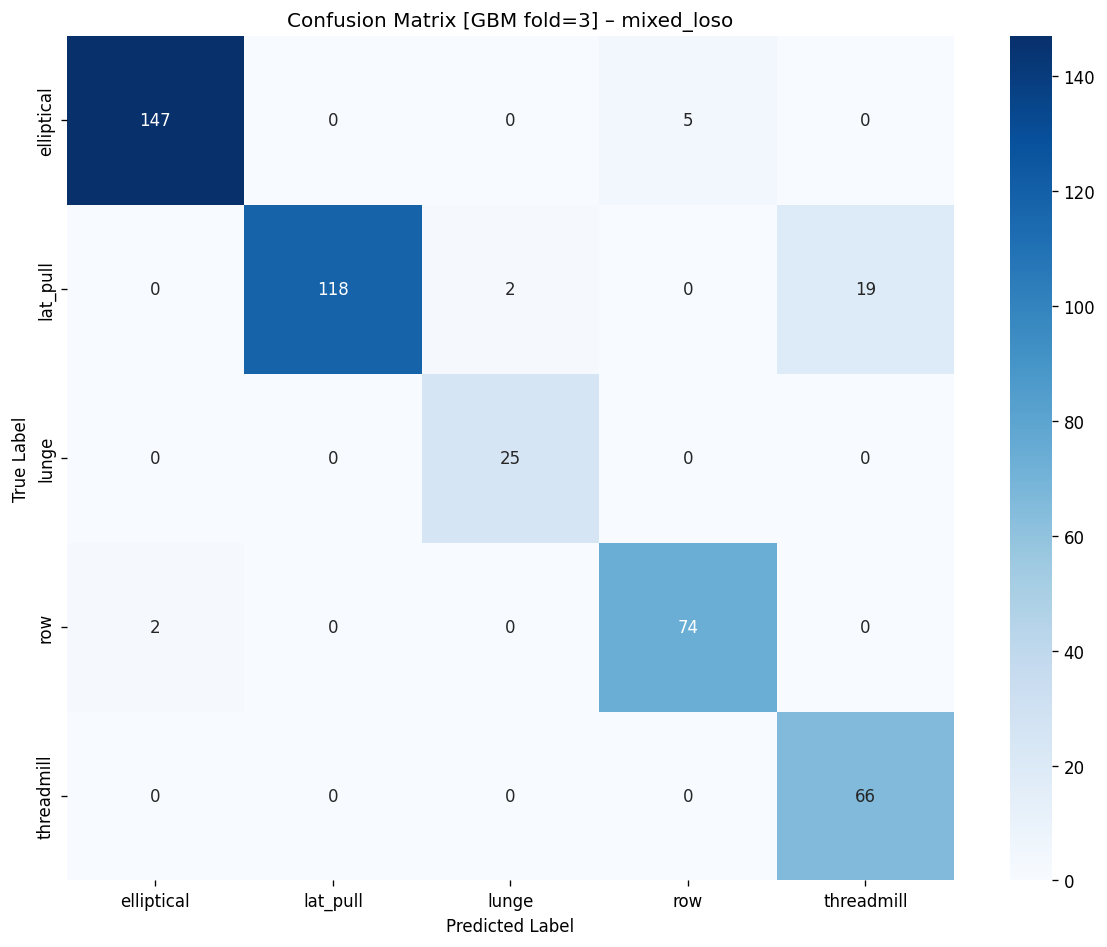


  Mixed-LOSO fold 4/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2079, test=554)

Test Accuracy [GBM fold=4]: 0.9639
              precision    recall  f1-score   support

  elliptical       0.99      0.91      0.95       186
    lat_pull       0.89      1.00      0.94       131
       lunge       1.00      0.96      0.98        27
         row       0.96      1.00      0.98        51
  threadmill       1.00      0.99      0.99       159

    accuracy                           0.96       554
   macro avg       0.97      0.97      0.97       554
weighted avg       0.97      0.96      0.96       554



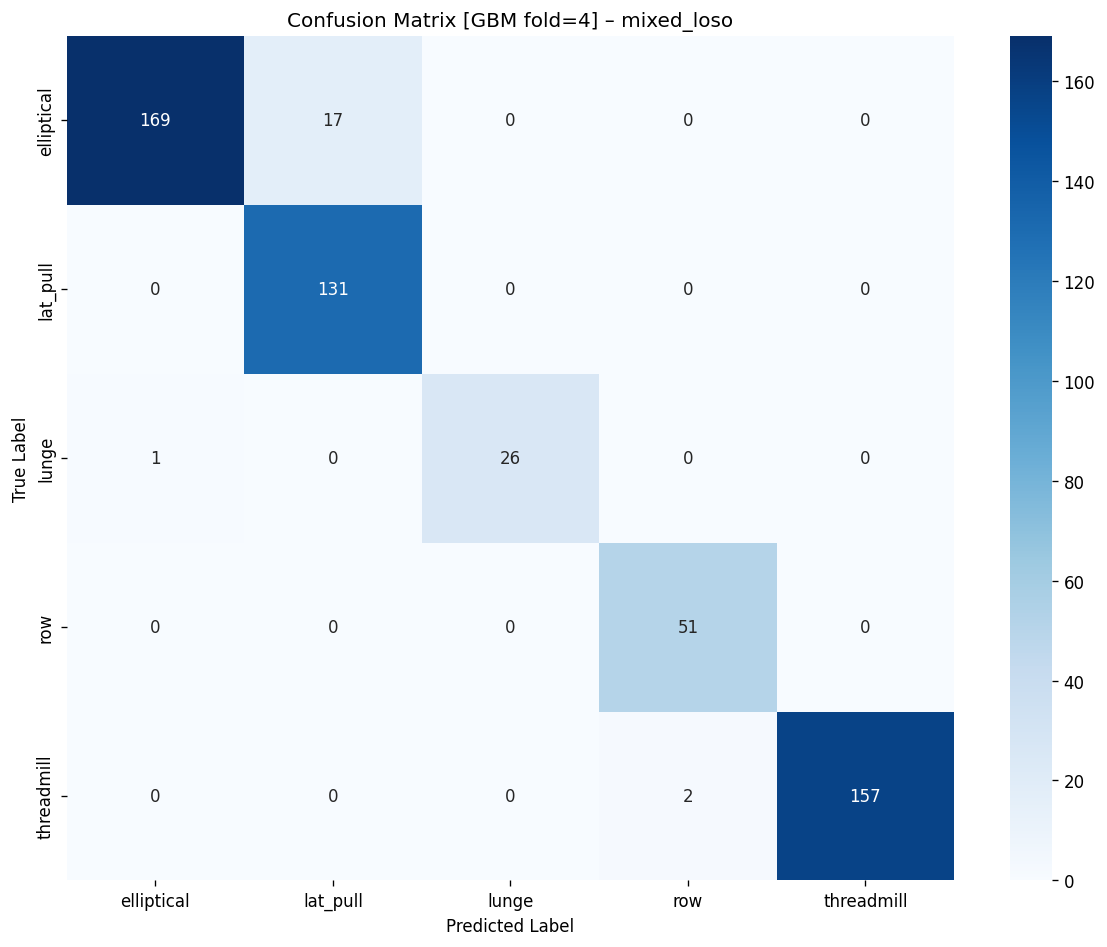


  Mixed-LOSO fold 5/5: participants in test=[np.str_('imaan'), np.str_('richard')]  (train=2121, test=512)

Test Accuracy [GBM fold=5]: 0.9980
              precision    recall  f1-score   support

  elliptical       1.00      0.99      1.00       138
    lat_pull       1.00      1.00      1.00        96
         row       0.99      1.00      0.99        96
  threadmill       1.00      1.00      1.00       182

    accuracy                           1.00       512
   macro avg       1.00      1.00      1.00       512
weighted avg       1.00      1.00      1.00       512



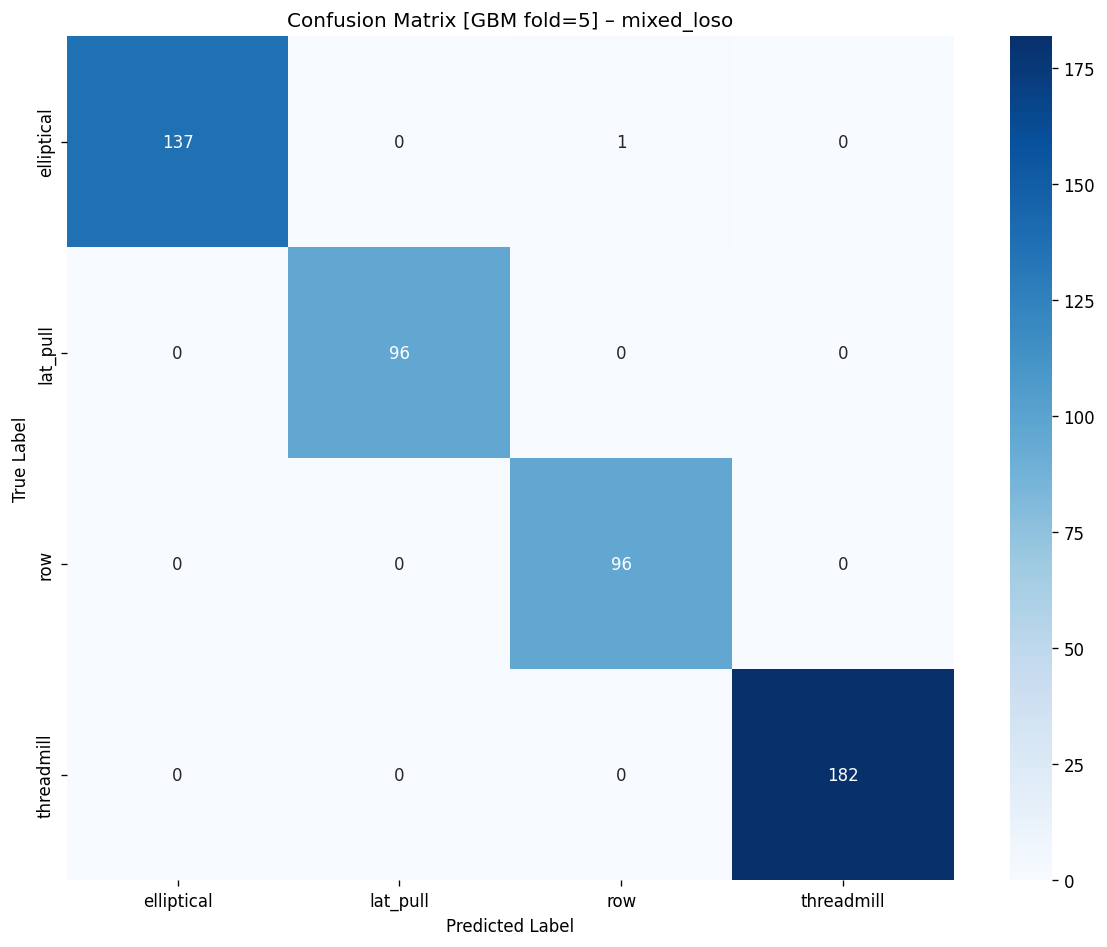


  Mixed-LOSO Mean Accuracy (GBM): 0.9659
  Per-fold: {'fold_1': 0.9686985172981878, 'fold_2': 0.9601593625498008, 'fold_3': 0.9388646288209607, 'fold_4': 0.9638989169675091, 'fold_5': 0.998046875}

=== Classical Model Mixed-LOSO Summary ===
  RF  : mean accuracy = 0.9684  | per-fold = {'fold_1': 0.9686985172981878, 'fold_2': 0.9581673306772909, 'fold_3': 0.9497816593886463, 'fold_4': 0.9675090252707581, 'fold_5': 0.998046875}
  SVM : mean accuracy = 0.9623  | per-fold = {'fold_1': 0.9654036243822076, 'fold_2': 0.9442231075697212, 'fold_3': 0.9519650655021834, 'fold_4': 0.9693140794223827, 'fold_5': 0.98046875}
  GBM : mean accuracy = 0.9659  | per-fold = {'fold_1': 0.9686985172981878, 'fold_2': 0.9601593625498008, 'fold_3': 0.9388646288209607, 'fold_4': 0.9638989169675091, 'fold_5': 0.998046875}


In [6]:
# ── 6. CLASSICAL ML – MIXED-LOSO EVALUATION (Point 5) ────────────────────────
# Each fold holds out ~1/5 of sessions from BOTH participants, so train and
# test always contain a mix of imaan (smartwatch) and richard (iPhone).
# Combined with gravity-aligned features this removes device-orientation bias.

classical_results = {}
classical_models = {}

for model_type in ["rf", "svm", "gbm"]:
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} – Mixed-LOSO")
    print(f"{'='*60}")
    trained_model, trained_scaler, res = train_with_validation(
        features, labels, feature_names, metadata,
        validation_strategy="mixed_loso",
        model_type=model_type,
    )
    classical_results[model_type] = res
    classical_models[model_type] = (trained_model, trained_scaler)

rf_model = classical_models["rf"][0]

print("\n=== Classical Model Mixed-LOSO Summary ===")
for mt, res in classical_results.items():
    print(f"  {mt.upper():4s}: mean accuracy = {res['mean_accuracy']:.4f}  "
          f"| per-fold = {res['per_fold_accuracy']}")


Gym Movements Deep Learning Pipeline (LOSO Evaluation)

Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 175,573
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']
  Sessions      : 74
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z', 'orient_qz', 'orient_qy', 'orient_qx', 'orient_qw', 'orient_roll', 'orient_pitch', 'orient_yaw', 'magnet_x', 'magnet_y', 'magnet_z', 'acc_vert', 'acc_horiz', 'gyro_vert', 'gyro_horiz', 'activity_label', 'participant', 'session', 'data_source']
Total samples: 175573
Participants: ['imaan', 'richard']
Activities: ['elliptical', 'lat_pull', 'lunge', 'row', 'threadmill']

=== Missing Value Analysis ===
Missing values per channel:
acc_x     0
acc_y     0
acc_z     0
gyro_x    3
gyro_y    3
gyro_z    3

Total missing: 9 — applying linear interpolation per session

Creating adaptive windows...

Window cre

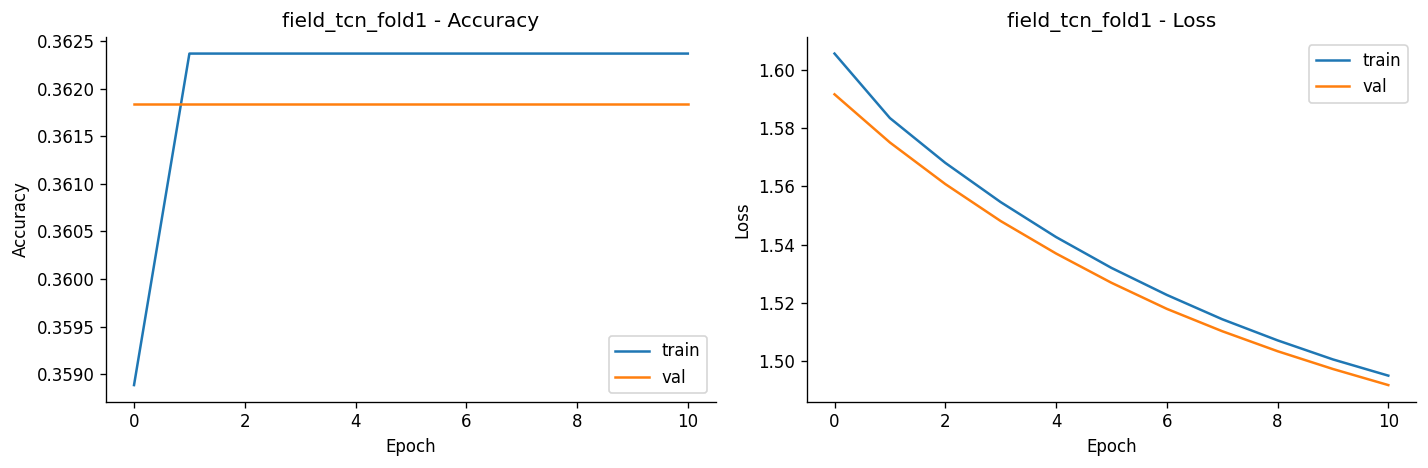


Training LSTM (fold 1)...
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4361 - loss: 1.4799 - val_accuracy: 0.3618 - val_loss: 1.5921 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3624 - loss: 1.5838 - val_accuracy: 0.3618 - val_loss: 1.5750 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3624 - loss: 1.5679 - val_accuracy: 0.3618 - val_loss: 1.5604 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3624 - loss: 1.5542 - val_accuracy: 0.3618 - val_loss: 1.5475 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3624 - loss: 1.5421 - val_accuracy: 0.3618 - val_loss: 1.5362 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3624 - loss: 1.5314 - val_accuracy: 0.3618 - val_loss: 1.5262 - learning_rate: 0.0010
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.36

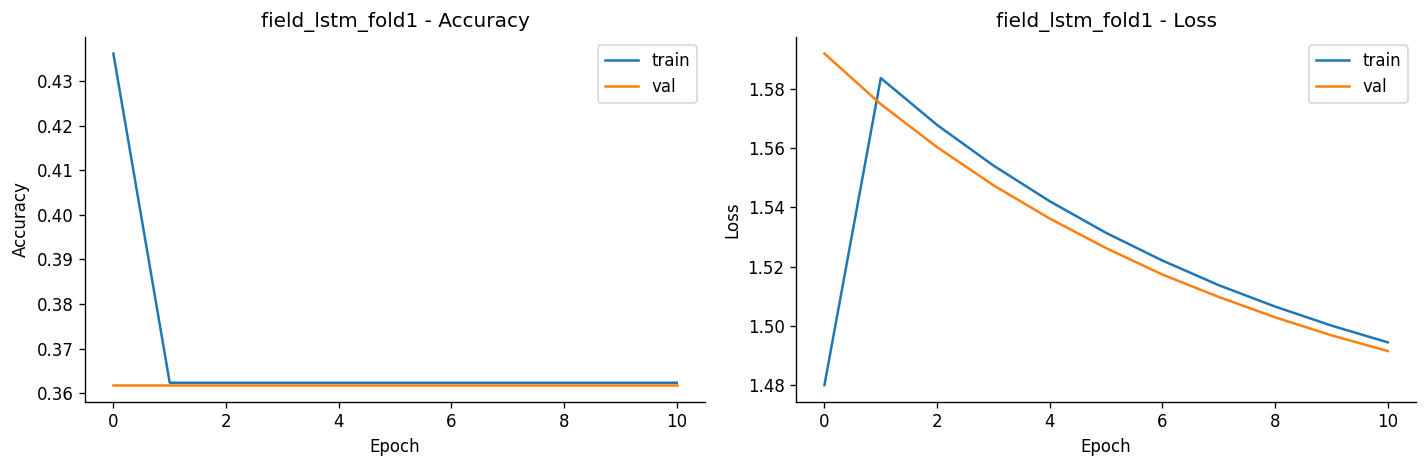


Training CNN_LSTM (fold 1)...
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3548 - loss: 1.5978 - val_accuracy: 0.3618 - val_loss: 1.5912 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3624 - loss: 1.5832 - val_accuracy: 0.3618 - val_loss: 1.5749 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3624 - loss: 1.5680 - val_accuracy: 0.3618 - val_loss: 1.5609 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3624 - loss: 1.5547 - val_accuracy: 0.3618 - val_loss: 1.5482 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3624 - loss: 1.5428 - val_accuracy: 0.3618 - val_loss: 1.5371 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3624 - loss: 1.5322 - val_accuracy: 0.3618 - val_loss: 1.5273 - learning_rate: 0.0010
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 

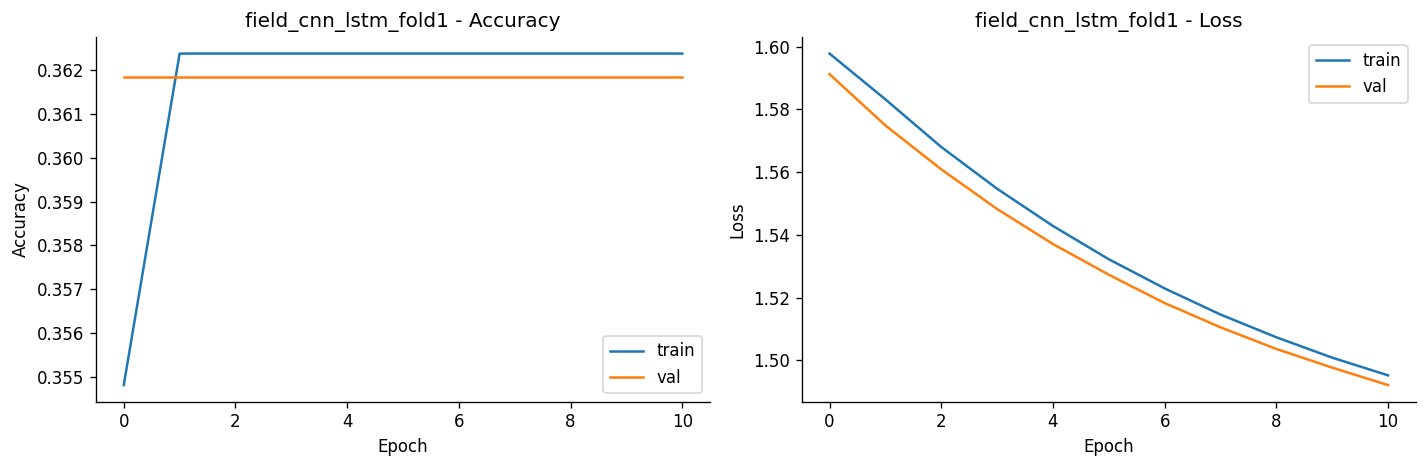


Mixed-LOSO fold 2/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2131, Test samples: 502

Training TCN (fold 2)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3506 - loss: 1.5034 - val_accuracy: 0.3406 - val_loss: 1.5897 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3407 - loss: 1.5806 - val_accuracy: 0.3406 - val_loss: 1.5713 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3407 - loss: 1.5636 - val_accuracy: 0.3406 - val_loss: 1.5555 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3407 - loss: 1.5489 - val_accuracy: 0.3406 - val_loss: 1.5417 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3407 - loss: 1.5364 - val_accuracy: 0.3406 - val_loss: 1.5300 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3407 - loss: 1.5256 - val_accuracy: 

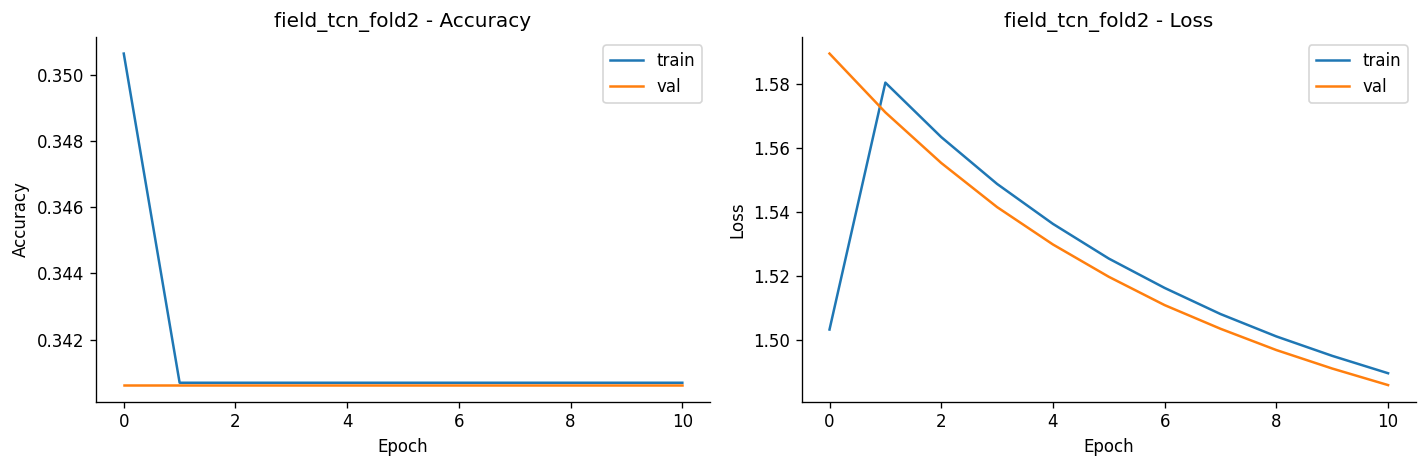


Training LSTM (fold 2)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3335 - loss: 1.5906 - val_accuracy: 0.3406 - val_loss: 1.5897 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3407 - loss: 1.5811 - val_accuracy: 0.3406 - val_loss: 1.5721 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3407 - loss: 1.5647 - val_accuracy: 0.3406 - val_loss: 1.5565 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3407 - loss: 1.5504 - val_accuracy: 0.3406 - val_loss: 1.5431 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3407 - loss: 1.5378 - val_accuracy: 0.3406 - val_loss: 1.5316 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3407 - loss: 1.5270 - val_accuracy: 0.3406 - val_loss: 1.5211 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.34

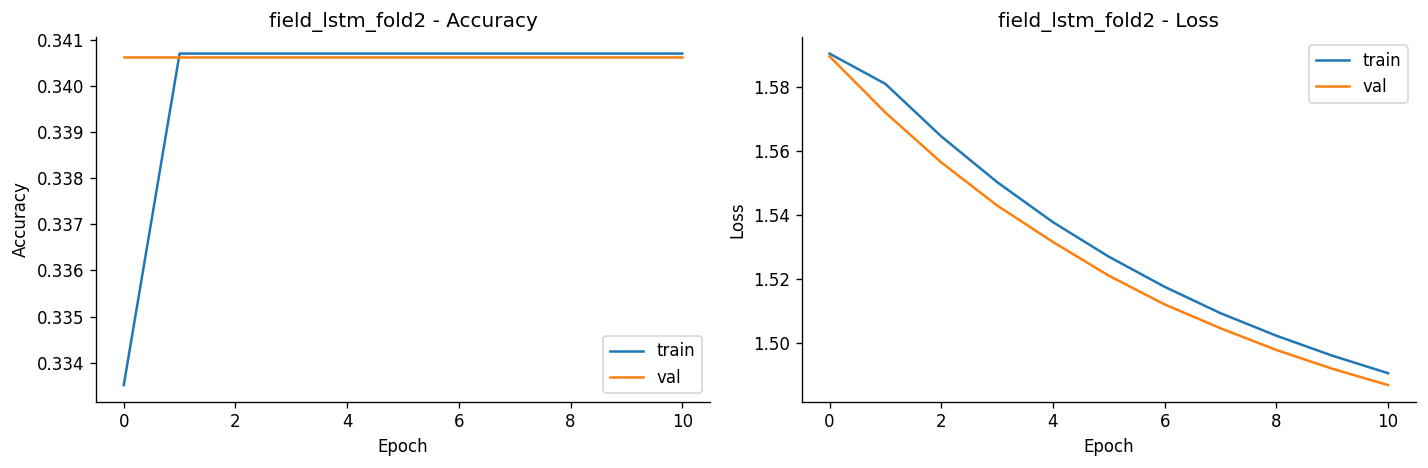


Training CNN_LSTM (fold 2)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3368 - loss: 1.5999 - val_accuracy: 0.3406 - val_loss: 1.5895 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3407 - loss: 1.5810 - val_accuracy: 0.3406 - val_loss: 1.5719 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3407 - loss: 1.5648 - val_accuracy: 0.3406 - val_loss: 1.5565 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3407 - loss: 1.5507 - val_accuracy: 0.3406 - val_loss: 1.5433 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3407 - loss: 1.5383 - val_accuracy: 0.3406 - val_loss: 1.5319 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3407 - loss: 1.5275 - val_accuracy: 0.3406 - val_loss: 1.5218 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 

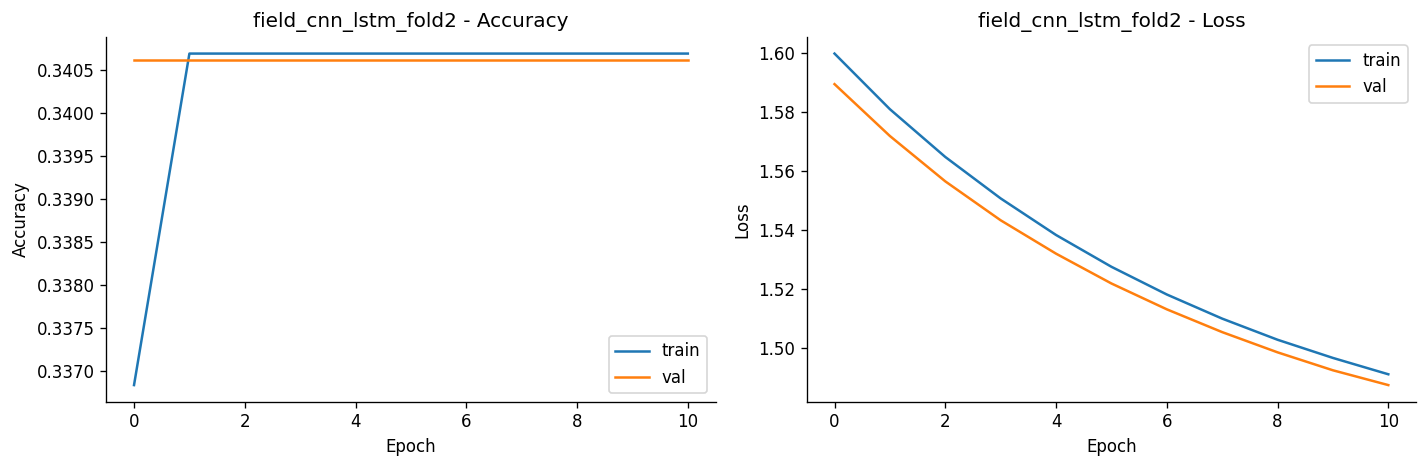


Mixed-LOSO fold 3/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2175, Test samples: 458

Training TCN (fold 3)...
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3712 - loss: 1.5964 - val_accuracy: 0.3823 - val_loss: 1.5863 - learning_rate: 0.0010
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3826 - loss: 1.5762 - val_accuracy: 0.3823 - val_loss: 1.5658 - learning_rate: 0.0010
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3826 - loss: 1.5568 - val_accuracy: 0.3823 - val_loss: 1.5477 - learning_rate: 0.0010
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3826 - loss: 1.5400 - val_accuracy: 0.3823 - val_loss: 1.5320 - learning_rate: 0.0010
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3826 - loss: 1.5253 - val_accuracy: 0.3823 - val_loss: 1.5182 - learning_rate: 0.0010
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3826 - loss: 1.5126 - val_accuracy: 

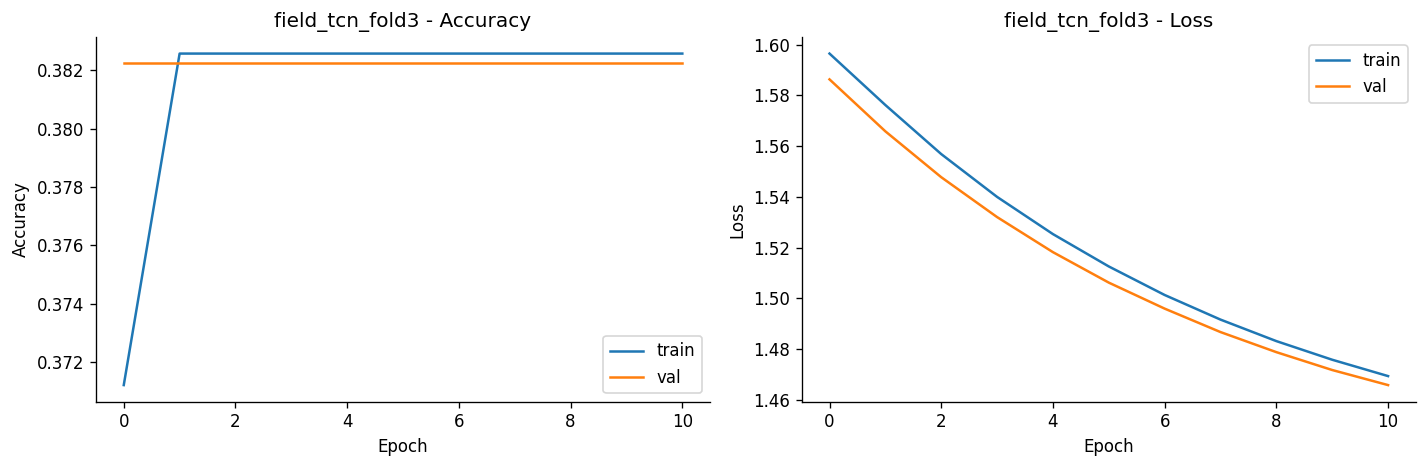


Training LSTM (fold 3)...
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.3620 - loss: 1.5991 - val_accuracy: 0.3823 - val_loss: 1.5866 - learning_rate: 0.0010
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3826 - loss: 1.5767 - val_accuracy: 0.3823 - val_loss: 1.5661 - learning_rate: 0.0010
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.3826 - loss: 1.5576 - val_accuracy: 0.3823 - val_loss: 1.5486 - learning_rate: 0.0010
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3826 - loss: 1.5410 - val_accuracy: 0.3823 - val_loss: 1.5328 - learning_rate: 0.0010
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3826 - loss: 1.5264 - val_accuracy: 0.3823 - val_loss: 1.5192 - learning_rate: 0.0010
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.3826 - loss: 1.5135 - val_accuracy: 0.3823 - val_loss: 1.5073 - learning_rate: 0.0010
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.38

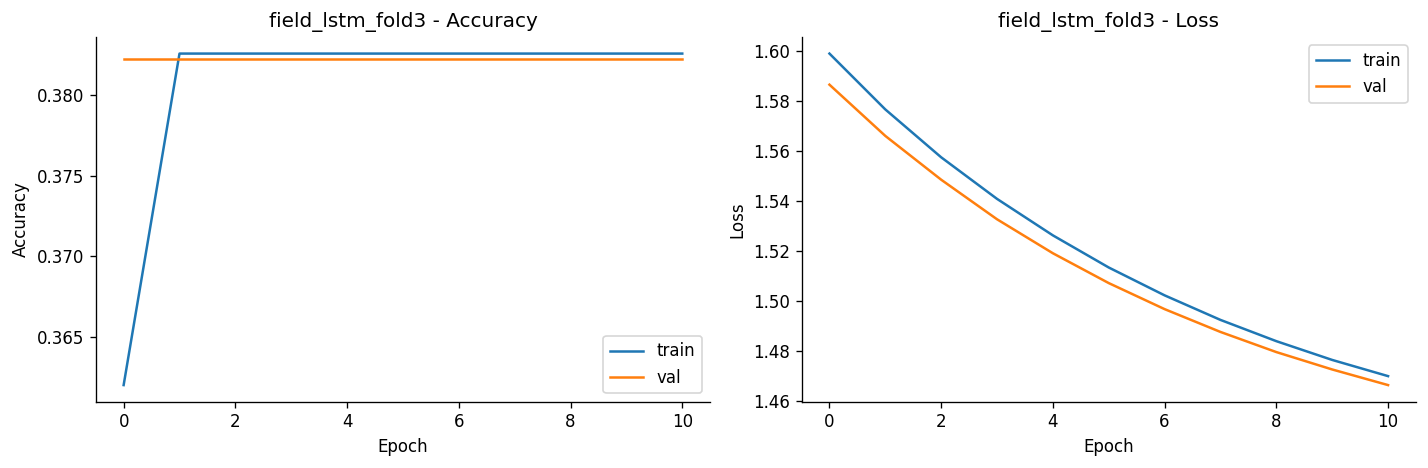


Training CNN_LSTM (fold 3)...
Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4351 - loss: 1.4991 - val_accuracy: 0.3823 - val_loss: 1.5870 - learning_rate: 0.0010
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3826 - loss: 1.5765 - val_accuracy: 0.3823 - val_loss: 1.5656 - learning_rate: 0.0010
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3826 - loss: 1.5567 - val_accuracy: 0.3823 - val_loss: 1.5474 - learning_rate: 0.0010
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3826 - loss: 1.5396 - val_accuracy: 0.3823 - val_loss: 1.5315 - learning_rate: 0.0010
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3826 - loss: 1.5248 - val_accuracy: 0.3823 - val_loss: 1.5174 - learning_rate: 0.0010
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3826 - loss: 1.5118 - val_accuracy: 0.3823 - val_loss: 1.5056 - learning_rate: 0.0010
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 

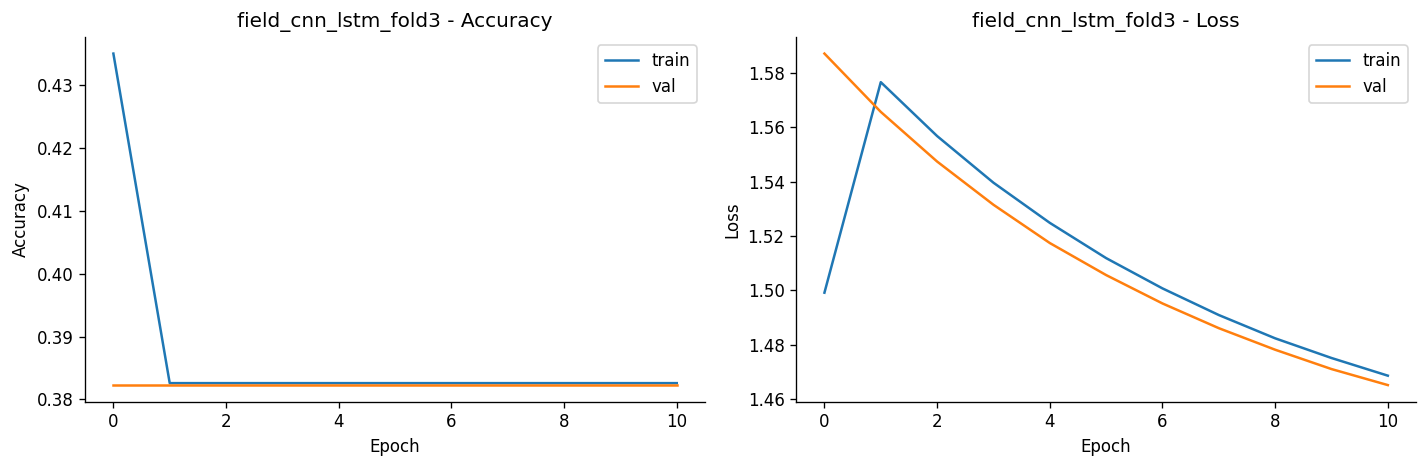


Mixed-LOSO fold 4/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2079, Test samples: 554

Training TCN (fold 4)...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.3780 - loss: 1.6045 - val_accuracy: 0.3846 - val_loss: 1.5899 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3837 - loss: 1.5816 - val_accuracy: 0.3846 - val_loss: 1.5722 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3837 - loss: 1.5649 - val_accuracy: 0.3846 - val_loss: 1.5567 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3837 - loss: 1.5503 - val_accuracy: 0.3846 - val_loss: 1.5427 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3837 - loss: 1.5372 - val_accuracy: 0.3846 - val_loss: 1.5306 - learning_rate: 0.0010
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3837 - loss: 1.5259 - val_accuracy: 

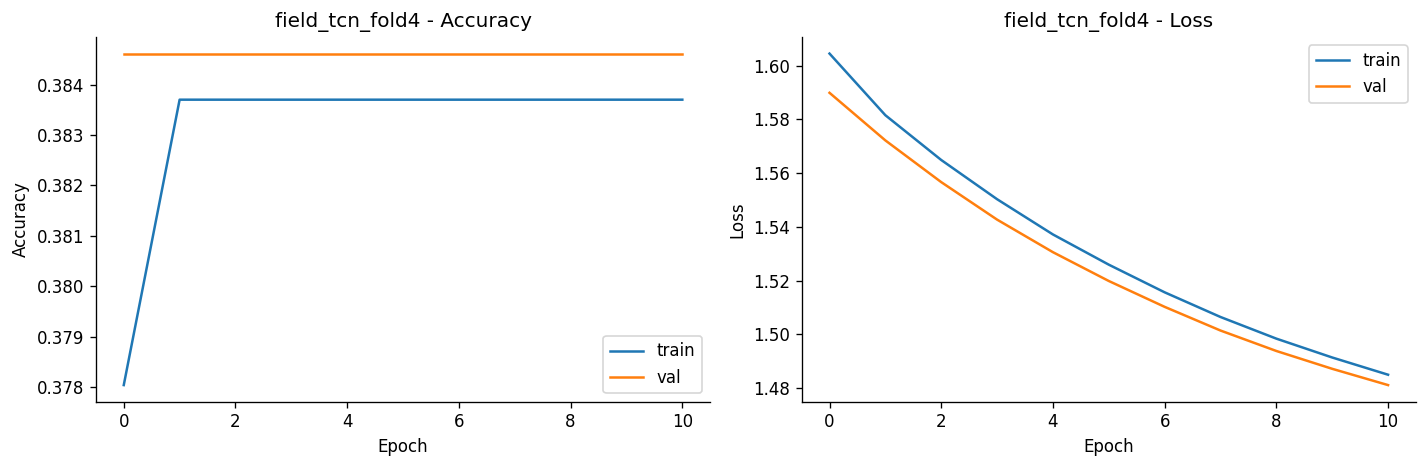


Training LSTM (fold 4)...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.3814 - loss: 1.5965 - val_accuracy: 0.3846 - val_loss: 1.5897 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3837 - loss: 1.5814 - val_accuracy: 0.3846 - val_loss: 1.5721 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3837 - loss: 1.5648 - val_accuracy: 0.3846 - val_loss: 1.5566 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3837 - loss: 1.5500 - val_accuracy: 0.3846 - val_loss: 1.5427 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3837 - loss: 1.5369 - val_accuracy: 0.3846 - val_loss: 1.5303 - learning_rate: 0.0010
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3837 - loss: 1.5252 - val_accuracy: 0.3846 - val_loss: 1.5190 - learning_rate: 0.0010
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.38

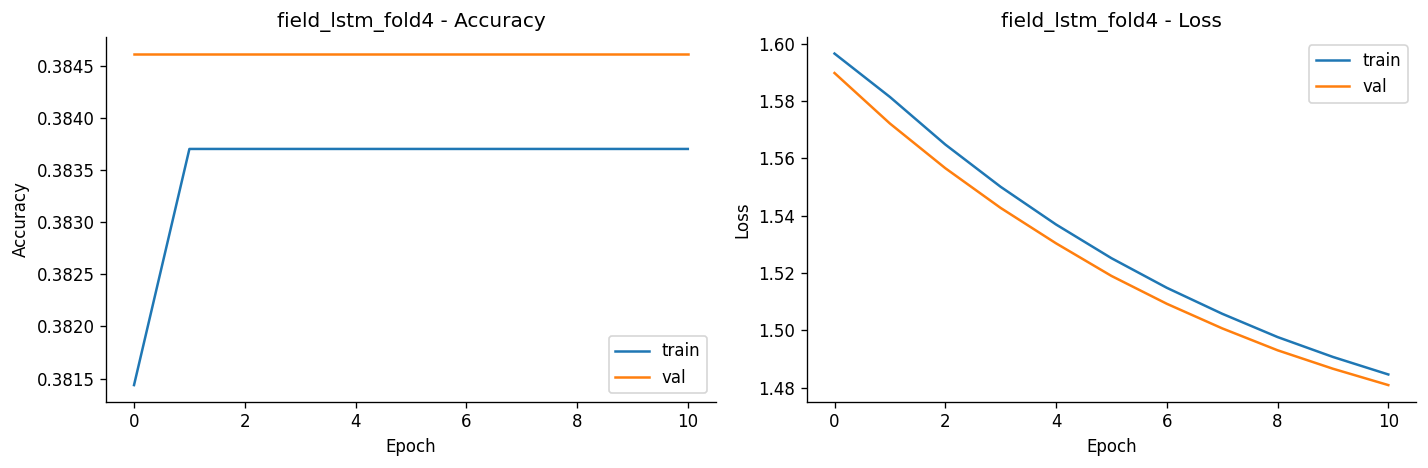


Training CNN_LSTM (fold 4)...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3860 - loss: 1.5771 - val_accuracy: 0.3846 - val_loss: 1.5898 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3837 - loss: 1.5814 - val_accuracy: 0.3846 - val_loss: 1.5721 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3837 - loss: 1.5647 - val_accuracy: 0.3846 - val_loss: 1.5563 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3837 - loss: 1.5499 - val_accuracy: 0.3846 - val_loss: 1.5421 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3837 - loss: 1.5368 - val_accuracy: 0.3846 - val_loss: 1.5300 - learning_rate: 0.0010
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3837 - loss: 1.5254 - val_accuracy: 0.3846 - val_loss: 1.5193 - learning_rate: 0.0010
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 

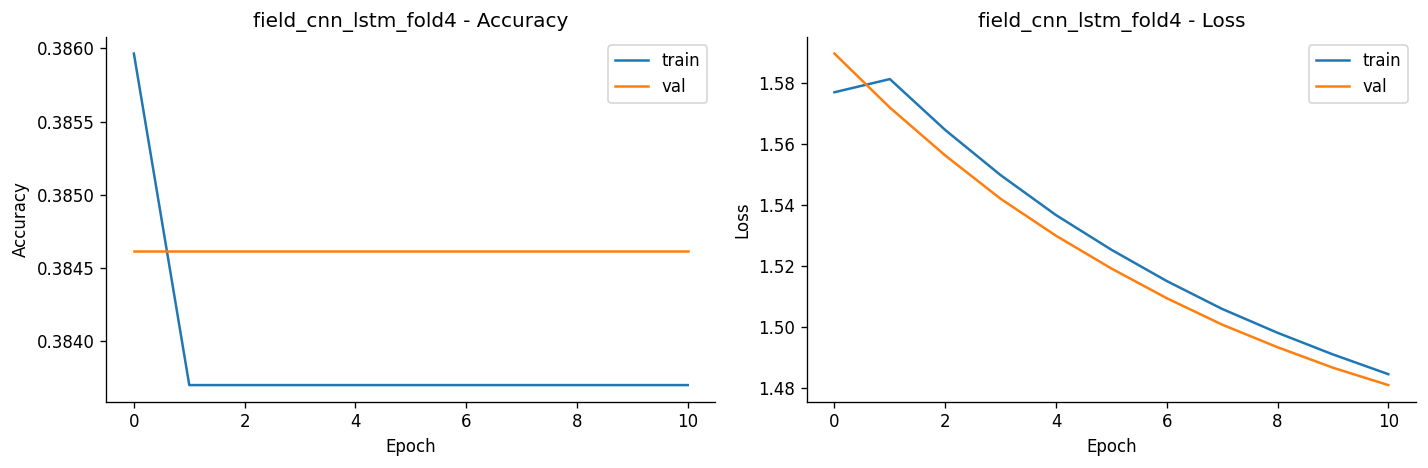


Mixed-LOSO fold 5/5: test participants=[np.str_('imaan'), np.str_('richard')]
Train samples: 2121, Test samples: 512

Training TCN (fold 5)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3729 - loss: 1.6079 - val_accuracy: 0.3981 - val_loss: 1.5896 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3990 - loss: 1.5804 - val_accuracy: 0.3981 - val_loss: 1.5710 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3990 - loss: 1.5630 - val_accuracy: 0.3981 - val_loss: 1.5548 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3990 - loss: 1.5475 - val_accuracy: 0.3981 - val_loss: 1.5403 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3990 - loss: 1.5335 - val_accuracy: 0.3981 - val_loss: 1.5277 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3990 - loss: 1.5213 - val_accuracy: 

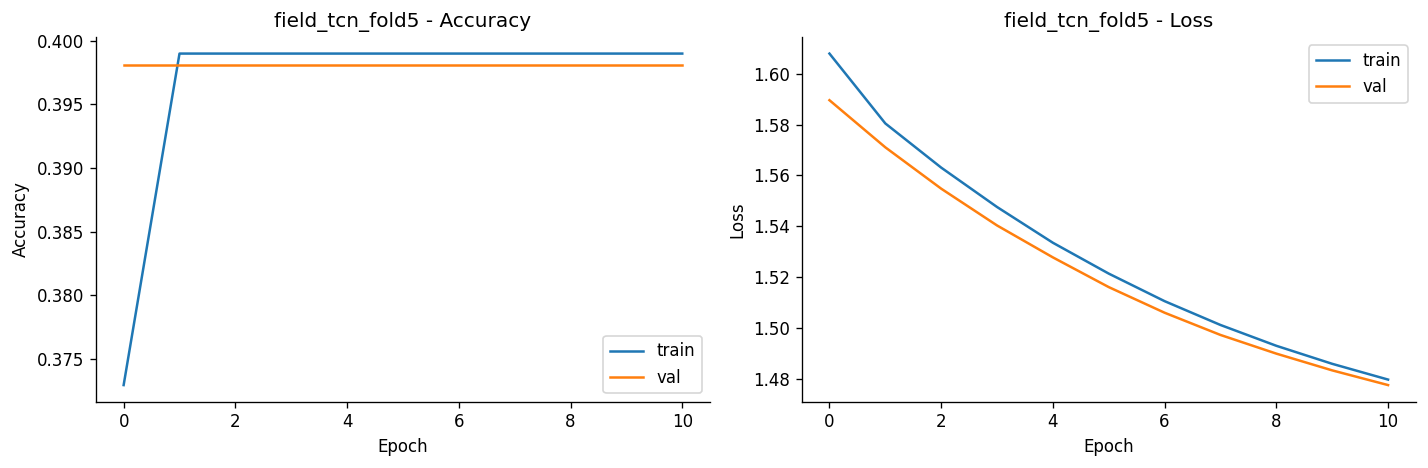


Training LSTM (fold 5)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4079 - loss: 1.5744 - val_accuracy: 0.3981 - val_loss: 1.5886 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3990 - loss: 1.5791 - val_accuracy: 0.3981 - val_loss: 1.5699 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3990 - loss: 1.5614 - val_accuracy: 0.3981 - val_loss: 1.5534 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.3990 - loss: 1.5460 - val_accuracy: 0.3981 - val_loss: 1.5387 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3990 - loss: 1.5323 - val_accuracy: 0.3981 - val_loss: 1.5261 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3990 - loss: 1.5204 - val_accuracy: 0.3981 - val_loss: 1.5152 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.39

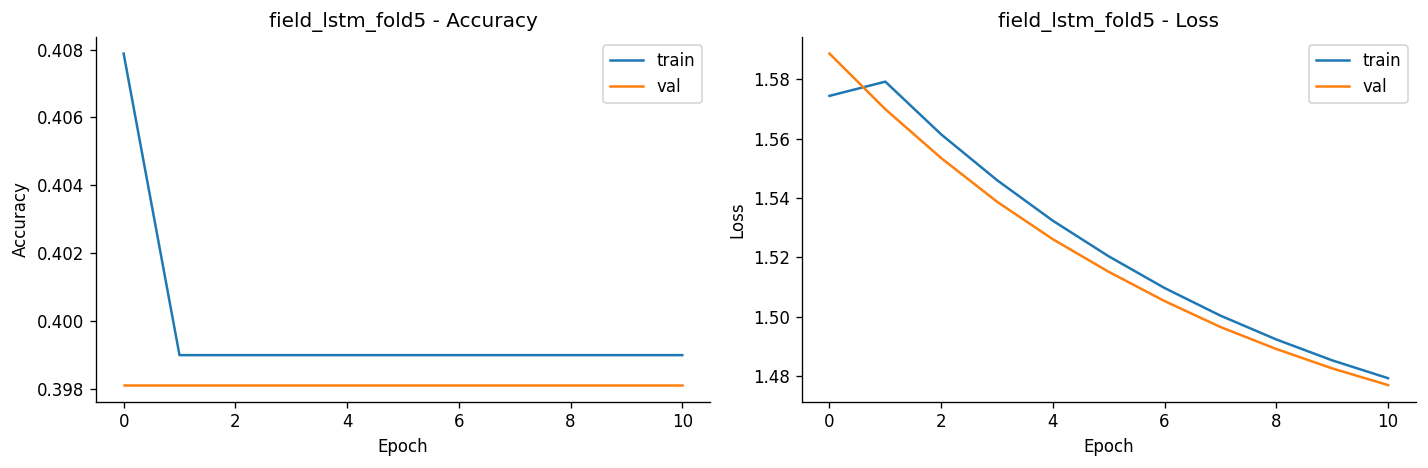


Training CNN_LSTM (fold 5)...
Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3929 - loss: 1.5983 - val_accuracy: 0.3981 - val_loss: 1.5888 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3990 - loss: 1.5795 - val_accuracy: 0.3981 - val_loss: 1.5701 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3990 - loss: 1.5619 - val_accuracy: 0.3981 - val_loss: 1.5538 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3990 - loss: 1.5465 - val_accuracy: 0.3981 - val_loss: 1.5395 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3990 - loss: 1.5328 - val_accuracy: 0.3981 - val_loss: 1.5267 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3990 - loss: 1.5207 - val_accuracy: 0.3981 - val_loss: 1.5155 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 

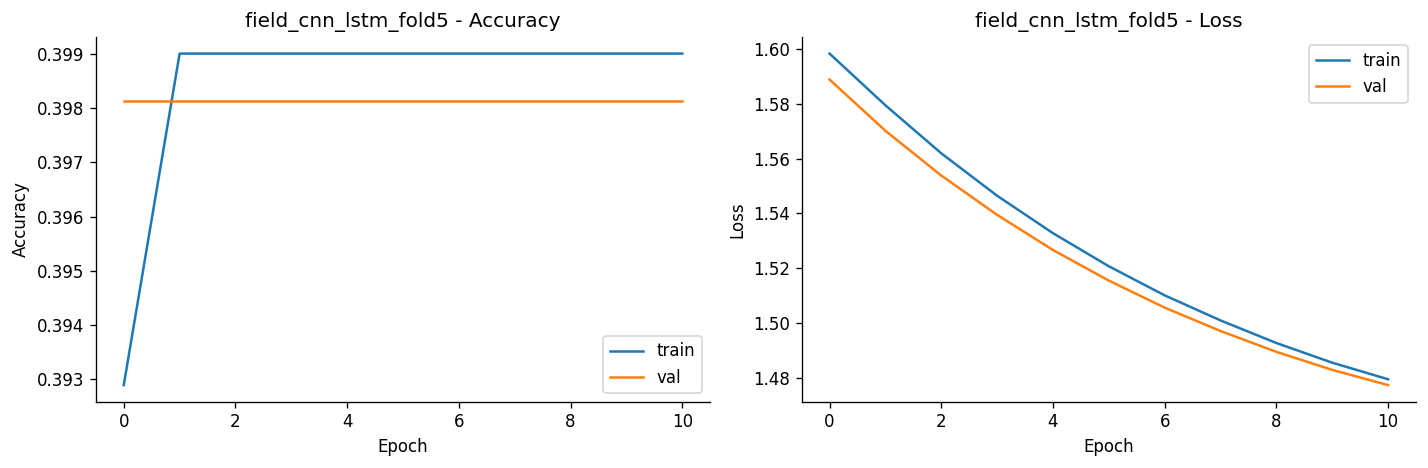


Mixed-LOSO Summary
  TCN       : per_fold=['0.4119', '0.5139', '0.3319', '0.3357', '0.2695']  ->  Mean = 0.3726
  LSTM      : per_fold=['0.4119', '0.5139', '0.3319', '0.3357', '0.2695']  ->  Mean = 0.3726
  CNN_LSTM  : per_fold=['0.4119', '0.5139', '0.3319', '0.3357', '0.2695']  ->  Mean = 0.3726


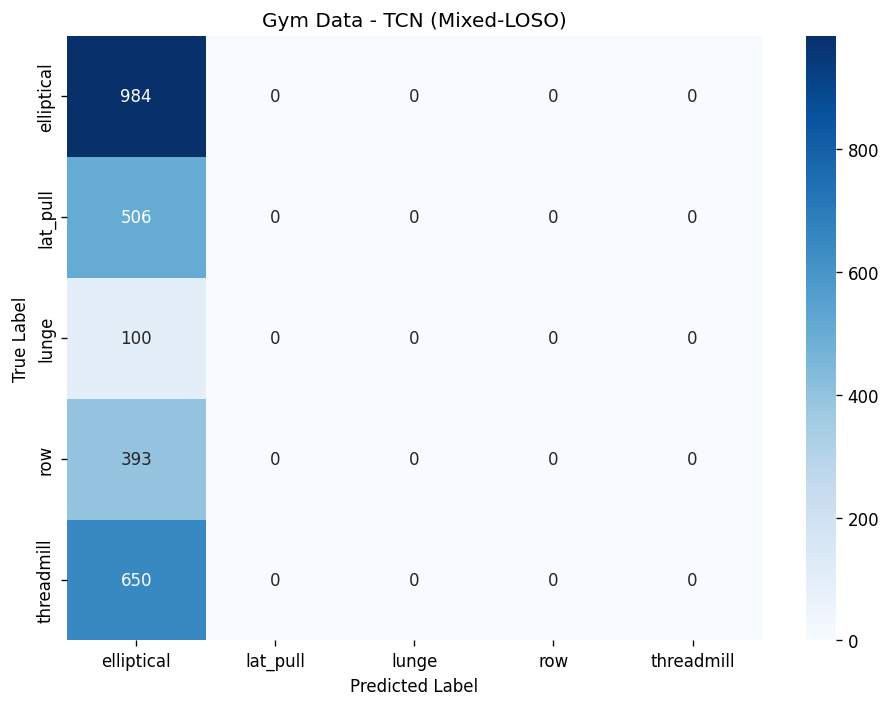

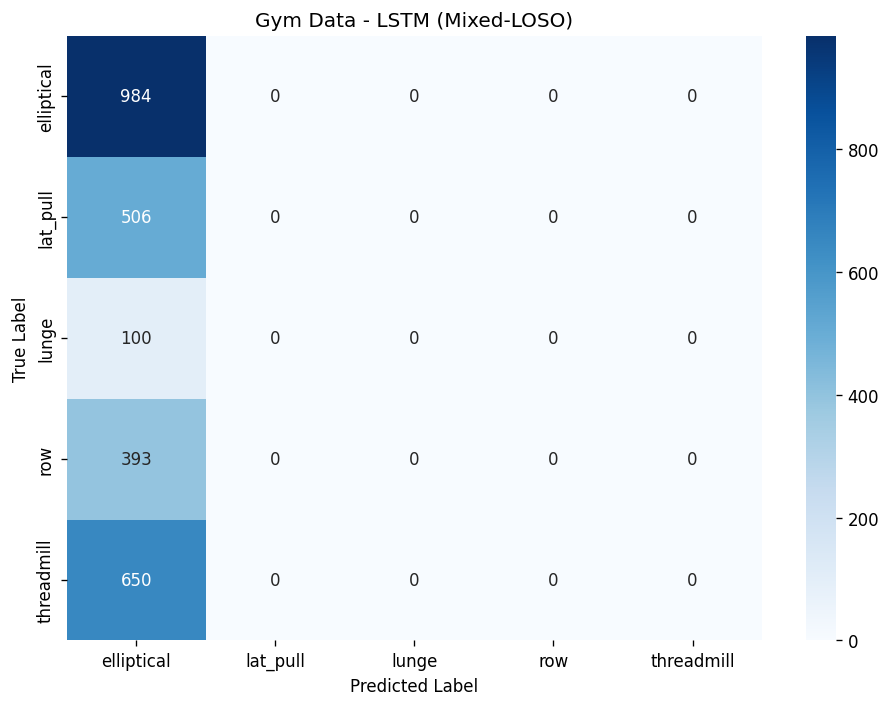

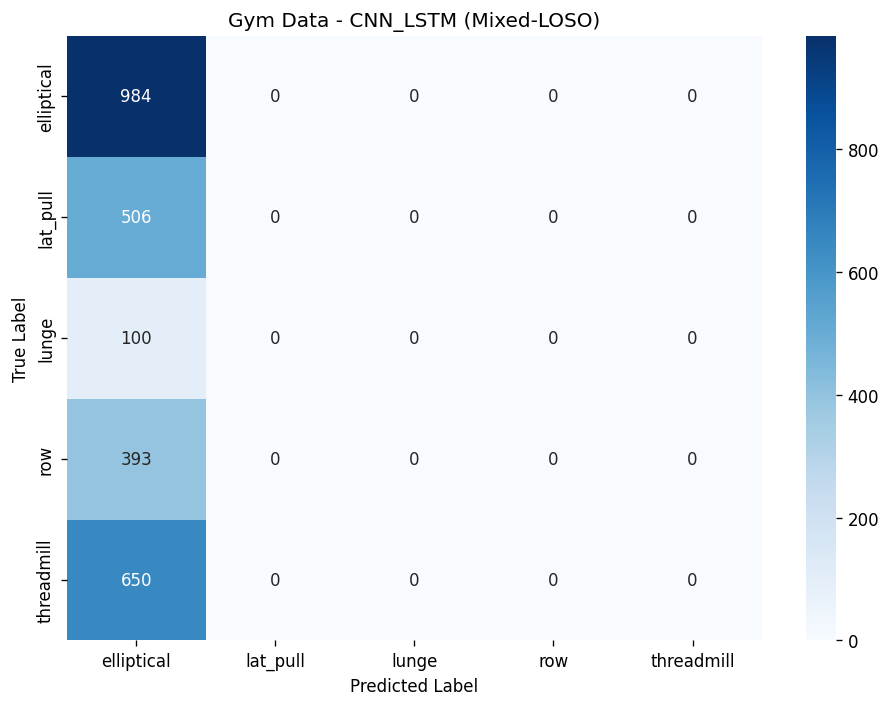


Results saved to: ./Models/Gym Models/dl_loso_results_20260611_220750.json

Model Comparison (mean LOSO accuracy)
  TCN         : 0.3726
  LSTM        : 0.3726
  CNN_LSTM    : 0.3726

  (RF model from cell 1 is available — re-run training.py with LOSO for RF accuracy)

Deep Learning Pipeline Complete

=== Deep Learning LOSO Summary ===
  TCN       : mean LOSO accuracy = 0.3726
  LSTM      : mean LOSO accuracy = 0.3726
  CNN_LSTM  : mean LOSO accuracy = 0.3726


In [7]:
# ── 7. DEEP LEARNING – LOSO EVALUATION (Point 6) ─────────────────────────────
# TCN, LSTM, CNN-LSTM trained on raw sequences with LOSO split.
# Uses Python.posthoc.get_training_summary which:
#   - reloads raw data
#   - handles missing values
#   - creates windows and sequences
#   - runs LOSO evaluation for all three DL models
#   - saves results + plots

from Python.posthoc import get_training_summary

dl_results, dl_summary = get_training_summary(rf_model=rf_model)

print("\n=== Deep Learning LOSO Summary ===")
for mt, s in dl_summary.items():
    print(f"  {mt.upper():10s}: mean LOSO accuracy = {s['mean']:.4f}")


=== Per-Activity Classification Report (RF LOSO, all folds) ===
              precision    recall  f1-score   support

  elliptical       0.98      0.98      0.98       984
    lat_pull       0.93      0.92      0.92       506
       lunge       0.96      0.99      0.98       100
         row       0.99      1.00      0.99       393
  threadmill       0.97      0.97      0.97       650

    accuracy                           0.97      2633
   macro avg       0.97      0.97      0.97      2633
weighted avg       0.97      0.97      0.97      2633



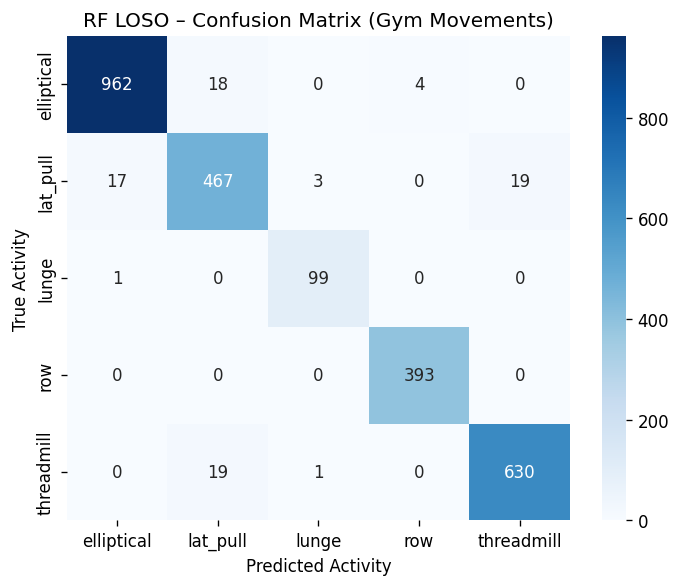


Samples per activity (windows):
  elliptical     : 984
  lat_pull       : 506
  lunge          : 100
  row            : 393
  threadmill     : 650


In [8]:
# ── 8. PER-ACTIVITY ACCURACY BREAKDOWN ───────────────────────────────────────
# Analyse which gym movement is hardest to classify by looking at per-class
# precision / recall from the aggregated LOSO predictions of the best classical model.

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Use the RF LOSO predictions (all folds combined)
rf_res = classical_results["rf"]
y_true_all = np.array(rf_res["all_true"])
y_pred_all = np.array(rf_res["all_pred"])
activities = sorted(set(y_true_all))

print("=== Per-Activity Classification Report (RF LOSO, all folds) ===")
print(classification_report(y_true_all, y_pred_all, target_names=activities, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_all, y_pred_all, labels=activities)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=activities, yticklabels=activities, ax=ax,
)
ax.set_title("RF LOSO – Confusion Matrix (Gym Movements)")
ax.set_ylabel("True Activity")
ax.set_xlabel("Predicted Activity")
plt.tight_layout()
plt.savefig("./Plots/gym_rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-activity sample counts
print("\nSamples per activity (windows):")
unique, counts = np.unique(y_true_all, return_counts=True)
for act, cnt in zip(unique, counts):
    print(f"  {act:<15s}: {cnt}")


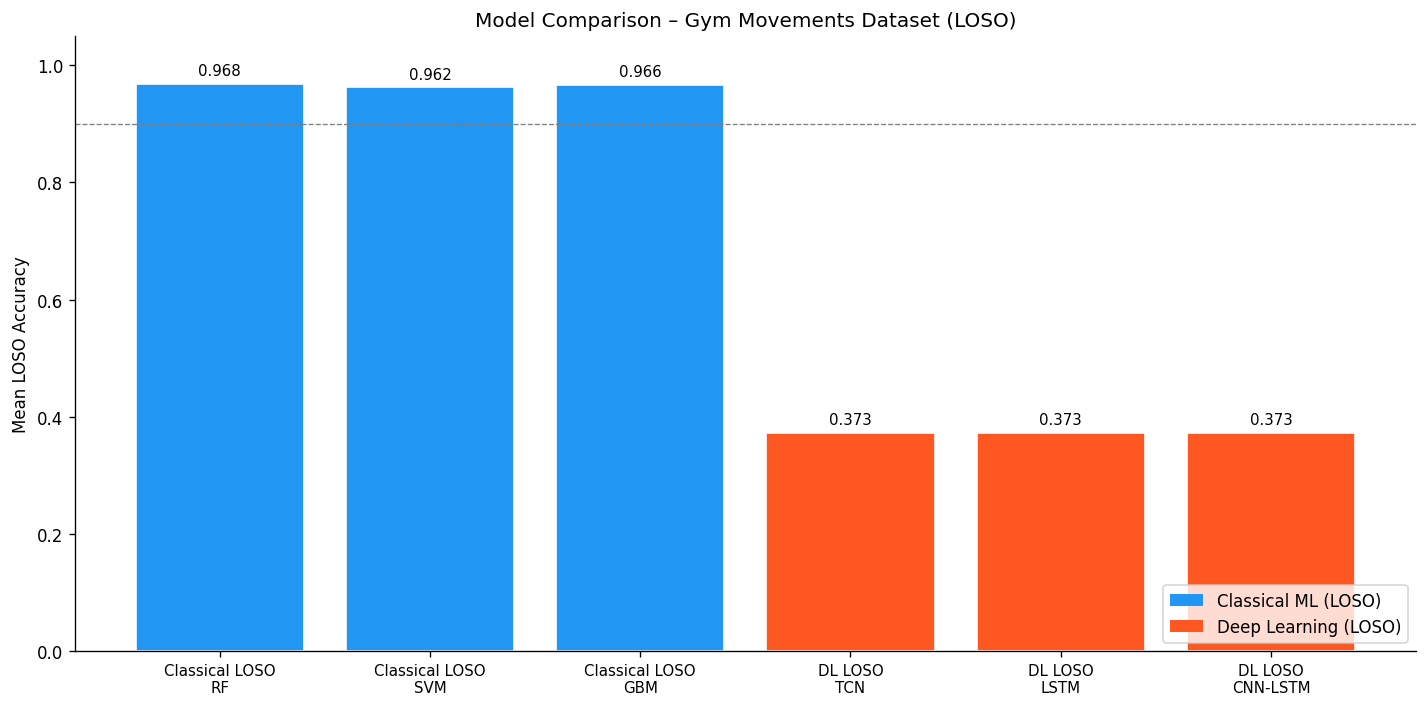


=== Final Results Table ===
Model                            Mean LOSO Accuracy
----------------------------------------------------
Classical LOSO – RF                                    0.9684
Classical LOSO – SVM                                   0.9623
Classical LOSO – GBM                                   0.9659
DL LOSO – TCN                                          0.3726
DL LOSO – LSTM                                         0.3726
DL LOSO – CNN-LSTM                                     0.3726


In [9]:
# ── 9. MODEL COMPARISON VISUALISATION ────────────────────────────────────────

# Collect results
all_accs = {}

# Classical LOSO
for mt, res in classical_results.items():
    all_accs[f"Classical LOSO\n{mt.upper()}"] = res["mean_accuracy"]

# Deep learning LOSO
for mt, s in dl_summary.items():
    label = {"tcn": "TCN", "lstm": "LSTM", "cnn_lstm": "CNN-LSTM"}.get(mt, mt.upper())
    all_accs[f"DL LOSO\n{label}"] = s["mean"]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = (
    ["#2196F3"] * len(classical_results)
    + ["#FF5722"] * len(dl_summary)
)
bars = ax.bar(list(all_accs.keys()), list(all_accs.values()), color=colors, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean LOSO Accuracy")
ax.set_title("Model Comparison – Gym Movements Dataset (LOSO)")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, label="0.90 reference")

for bar, val in zip(bars, all_accs.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{val:.3f}", ha="center", va="bottom", fontsize=9,
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Classical ML (LOSO)"),
    Patch(facecolor="#FF5722", label="Deep Learning (LOSO)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("./Plots/gym_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Final Results Table ===")
print(f"{'Model':<30} {'Mean LOSO Accuracy':>20}")
print("-" * 52)
for name, acc in all_accs.items():
    label = name.replace("\n", " – ")
    print(f"{label:<50} {acc:>10.4f}")
